# ECE 251A Numerical Assignment 1
## Classical and Deep Learning Based Power Spectrum Estimation


In [1]:

from __future__ import annotations

import itertools
import math
import random
import time
from copy import deepcopy
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "outputs_psd_assignment"
OUTPUT_DIR.mkdir(exist_ok=True)


In [2]:

SEED = 251
NEURAL_PROJECT_SEED = 7
NEURAL_INFERENCE_SEED = 99
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

N_VALUES = [64, 128, 256, 512, 1024]
N_MAIN = 1024
N_FFT = 2048

MC_TRIALS = 1500
ML_TRIALS = 500

DL_EPOCHS_SEARCH = 600
DL_EPOCHS_FINAL = 1200
DL_BATCH_SIZE = 0
P_VALUES_TO_TEST = [16, 32, 48, 64, 80, 96, 112, 128, 160]
P_MAX_AVAILABLE = max(P_VALUES_TO_TEST)


## Problem setup

The output random process is generated by filtering zero mean, unit variance Gaussian white noise through

$$
H(z)=\frac{1-0.9z^{-1}+0.81z^{-2}}
{1-2.76z^{-1}+3.809z^{-2}-2.654z^{-3}+0.924z^{-4}}.
$$

Let the input be $x[n]\sim \mathcal{N}(0,1)$, and let the system impulse response be $h[n]$. Then

$$
y[n] = \sum_{m=0}^{\infty} h[m]x[n-m].
$$

Because the input is white with variance 1, the true autocorrelation of $y[n]$ is

$$
r_y[k] = \mathbb{E}\{y[n]y[n-k]\}=\sum_m h[m]h[m+k],
$$

where the sum is over valid causal impulse response indices. The true PSD is

$$
S_y(e^{j\omega}) = |H(e^{j\omega})|^2.
$$


In [3]:
b = np.array([1.0, -0.9, 0.81], dtype=float)
a = np.array([1.0, -2.76, 3.809, -2.654, 0.924], dtype=float)


def H_of_w(w: np.ndarray) -> np.ndarray:
    """Evaluate the system frequency response."""
    w = np.asarray(w)
    num = sum(b[k] * np.exp(-1j * w * k) for k in range(len(b)))
    den = sum(a[k] * np.exp(-1j * w * k) for k in range(len(a)))
    return num / den


def fft_frequency_grid(n_fft: int) -> np.ndarray:
    """Build a centered FFT frequency grid."""
    return 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(n_fft, d=1.0))


def db(x: np.ndarray, floor: float = 0.000000000001) -> np.ndarray:
    """Convert power values to decibels."""
    return 10 * np.log10(np.maximum(np.asarray(x), floor))


IMPULSE_LEN = 16384
delta = np.zeros(IMPULSE_LEN)
delta[0] = 1.0
h_true_long = signal.lfilter(b, a, delta)

r_h_full = signal.correlate(h_true_long, h_true_long, mode="full", method="fft")
lags_h_full = np.arange(-(IMPULSE_LEN - 1), IMPULSE_LEN)


def true_autocorr_at_lags(lags: np.ndarray | list[int]) -> np.ndarray:
    """Evaluate true autocorrelation at integer lags."""
    lags = np.asarray(lags, dtype=int)
    return np.interp(lags, lags_h_full, r_h_full)


def generate_xy_pair(N: int, P: int, rng: np.random.Generator, burnin: int = 4096):
    """Generate one aligned input and output pair."""
    x_all = rng.normal(0.0, 1.0, size=burnin + P + N)
    y_all = signal.lfilter(b, a, x_all)
    x_store = x_all[burnin : burnin + P + N]
    y = y_all[burnin + P : burnin + P + N]
    return x_store.astype(np.float32), y.astype(np.float32)


def generate_y_realizations(num_realizations: int, N: int, rng: np.random.Generator, burnin: int = 4096):
    """Generate independent output realizations."""
    x_all = rng.normal(0.0, 1.0, size=(num_realizations, burnin + N))
    y_all = signal.lfilter(b, a, x_all, axis=1)
    return y_all[:, burnin:].astype(np.float32)


def generate_xy_realizations(num_realizations: int, N: int, P: int, rng: np.random.Generator, burnin: int = 4096):
    """Generate aligned input and output realizations."""
    x_all = rng.normal(0.0, 1.0, size=(num_realizations, burnin + P + N))
    y_all = signal.lfilter(b, a, x_all, axis=1)
    x_store = x_all[:, burnin : burnin + P + N]
    y = y_all[:, burnin + P : burnin + P + N]
    return x_store.astype(np.float32), y.astype(np.float32)


def sample_autocorr(y: np.ndarray, max_lag: int, unbiased: bool = False) -> np.ndarray:
    """Estimate autocorrelation for nonnegative lags."""
    y = np.asarray(y, dtype=float).reshape(-1)
    N = len(y)
    r = np.empty(max_lag + 1)
    for lag in range(max_lag + 1):
        r[lag] = np.dot(y[: N - lag], y[lag:]) / N
    return r


def raw_periodogram(y: np.ndarray, n_fft: int = N_FFT) -> np.ndarray:
    """Compute the raw periodogram."""
    y = np.asarray(y, dtype=float).reshape(-1)
    Y = np.fft.fftshift(np.fft.fft(y, n=n_fft))
    return (np.abs(Y) ** 2) / len(y)


def windowed_periodogram(y: np.ndarray, window: np.ndarray, n_fft: int = N_FFT) -> np.ndarray:
    """Compute a windowed periodogram."""
    y = np.asarray(y, dtype=float).reshape(-1)
    win = np.asarray(window, dtype=float).reshape(-1)
    Y = np.fft.fftshift(np.fft.fft(y * win, n=n_fft))
    return (np.abs(Y) ** 2) / np.sum(win ** 2)


def default_welch_params(N: int) -> dict:
    """Choose Welch segment settings."""
    nperseg = min(256, max(32, 2 ** int(np.floor(np.log2(N // 2)))))
    noverlap = nperseg // 2
    step = nperseg - noverlap
    starts = list(range(0, N - nperseg + 1, step))
    return {
        "N": N,
        "Ns_segment_length": nperseg,
        "R_overlap": noverlap,
        "step": step,
        "K_segments": len(starts),
        "window": "hann",
    }


def welch_periodogram(y: np.ndarray, nperseg: int, noverlap: int, n_fft: int = N_FFT, window_name: str = "hann") -> np.ndarray:
    """Compute a Welch periodogram estimate."""
    y = np.asarray(y, dtype=float).reshape(-1)
    step = nperseg - noverlap
    starts = range(0, len(y) - nperseg + 1, step)
    win = signal.windows.get_window(window_name, nperseg, fftbins=True)
    psds = [windowed_periodogram(y[s : s + nperseg], win, n_fft=n_fft) for s in starts]
    return np.mean(psds, axis=0)


def periodogram_stats(Y: np.ndarray, lengths: list[int], n_fft: int = N_FFT) -> dict[int, dict[str, np.ndarray]]:
    """Compute periodogram mean and variance."""
    stats = {}
    for N in lengths:
        I = np.stack([raw_periodogram(row[:N], n_fft=n_fft) for row in Y], axis=0)
        stats[N] = {"mean": I.mean(axis=0), "var": I.var(axis=0, ddof=1), "all": I}
    return stats


def welch_stats(Y: np.ndarray, lengths: list[int], n_fft: int = N_FFT) -> dict[int, dict[str, np.ndarray]]:
    """Compute Welch mean and variance."""
    stats = {}
    for N in lengths:
        p = default_welch_params(N)
        W = np.stack([
            welch_periodogram(row[:N], p["Ns_segment_length"], p["R_overlap"], n_fft=n_fft, window_name=p["window"])
            for row in Y
        ], axis=0)
        stats[N] = {"mean": W.mean(axis=0), "var": W.var(axis=0, ddof=1), "all": W, "params": p}
    return stats


def plot_psd_curve(w: np.ndarray, psd: np.ndarray, label: str, ax, use_db: bool = True, linewidth: float = 1.5, alpha: float = 1.0):
    """Plot a PSD curve."""
    ax.plot(w / np.pi, db(psd), label=label, linewidth=linewidth, alpha=alpha)
    ax.set_xlabel(r"Normalized frequency $\omega/\pi$")
    ax.set_ylabel("Power [dB]")
    return ax


w_grid = fft_frequency_grid(N_FFT)
S_true_grid = np.abs(H_of_w(w_grid)) ** 2


# Part I Periodogram Estimation

## (a) True autocorrelation function

The theoretical autocorrelation is computed from the impulse response:

$$
r_y[k] = \sum_m h[m]h[m+k].
$$

The code below visualizes the poles/zeros, impulse response, and true autocorrelation. The impulse response is truncated only for numerical plotting; the true autocorrelation approximation uses a much longer impulse response .


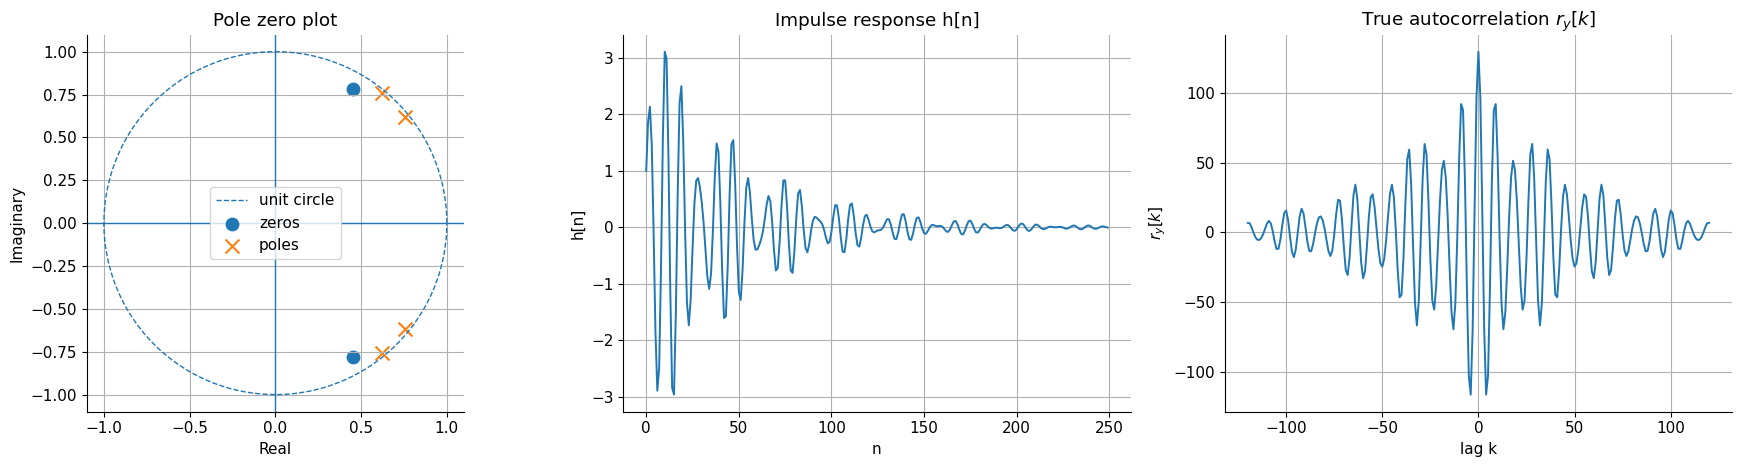

,quantity,value
0,maximum pole magnitude,0.982216


In [4]:
zeros = np.roots(b)
poles = np.roots(a)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

ax = axes[0]
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), linestyle="--", linewidth=1, label="unit circle")
ax.scatter(np.real(zeros), np.imag(zeros), marker="o", s=80, label="zeros")
ax.scatter(np.real(poles), np.imag(poles), marker="x", s=100, label="poles")
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Pole zero plot")
ax.set_xlabel("Real")
ax.set_ylabel("Imaginary")
ax.legend()

ax = axes[1]
imp_lags = np.arange(250)
ax.plot(imp_lags, h_true_long[:250], linewidth=1.4)
ax.set_title("Impulse response h[n]")
ax.set_xlabel("n")
ax.set_ylabel("h[n]")

ax = axes[2]
acf_lags = np.arange(-120, 121)
r_true_acf = true_autocorr_at_lags(acf_lags)
ax.plot(acf_lags, r_true_acf, linewidth=1.4)
ax.set_title(r"True autocorrelation $r_y[k]$")
ax.set_xlabel("lag k")
ax.set_ylabel(r"$r_y[k]$")

plt.tight_layout()
plt.show()

display(pd.DataFrame({"quantity": ["maximum pole magnitude"], "value": [float(np.max(np.abs(poles)))]}))


### Comments

- The pole-zero plot shows that the system is stable because all poles lie inside the unit circle, but the maximum pole magnitude 0.982216 is very close to one. This means the output process has resonantng memory rather than quickly dying correlation.
- The impulse response confirms this behavior: it decays slowly and oscillates, so many past input samples still influence each output sample. That long tail is the main reason short data records struggle in the later estimation tasks.
- The autocorrelation is even in lag and has the same oscillatory decay pattern as the impulse response energy overlap.
- Because the true autocorrelation remains non negligible over many lags, good agreement near lag zero is not enough; an estimator should also capture the sign changes and slower envelope decay across the plotted lag range.

## Generate one 1024 sample realization

The generated realization below is reused for the single realization comparisons in Parts I(b) and I(d). A larger prehistory is generated internally so the displayed output is approximately in steady state.


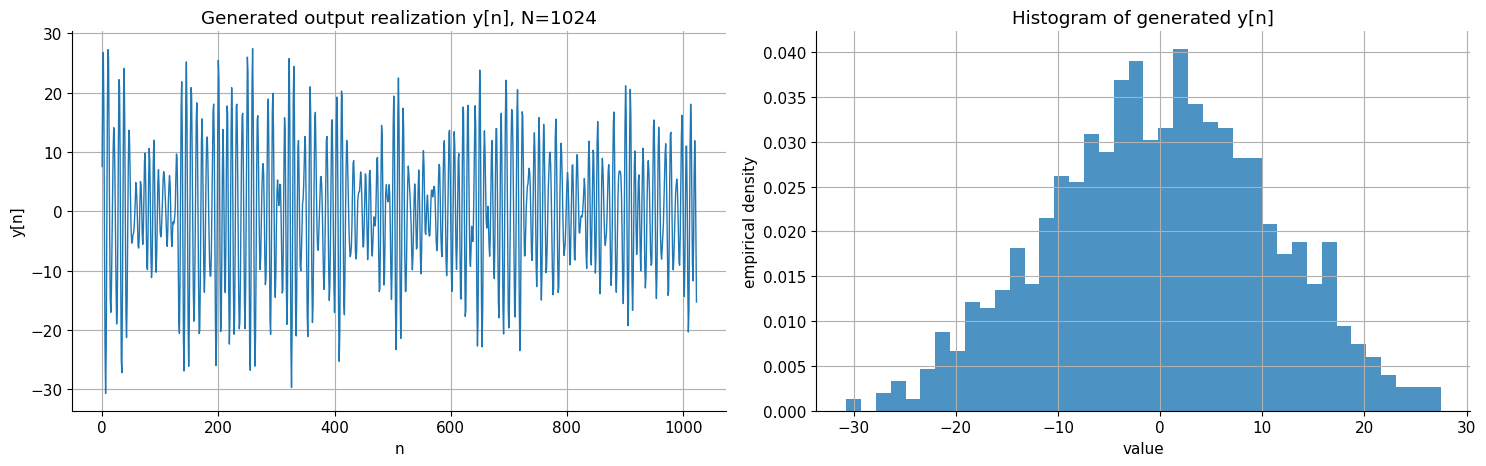

,quantity,value
0,sample mean,-0.012200
1,sample variance,116.384766
2,true variance r_y[0],129.481244


In [5]:
rng_main = np.random.default_rng(SEED)
x_master, y_main = generate_xy_pair(N=N_MAIN, P=P_MAX_AVAILABLE, rng=rng_main)

np.save(OUTPUT_DIR / "y_problem1.npy", y_main)


def x_for_lag(P: int) -> np.ndarray:
    """Slice stored input history for a lag value."""
    return x_master[P_MAX_AVAILABLE - P :].copy()


fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
axes[0].plot(y_main, linewidth=1.0)
axes[0].set_title("Generated output realization y[n], N=1024")
axes[0].set_xlabel("n")
axes[0].set_ylabel("y[n]")

axes[1].hist(y_main, bins=40, density=True, alpha=0.8)
axes[1].set_title("Histogram of generated y[n]")
axes[1].set_xlabel("value")
axes[1].set_ylabel("empirical density")

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "quantity": ["sample mean", "sample variance", "true variance r_y[0]"],
    "value": [float(np.mean(y_main)), float(np.var(y_main)), float(true_autocorr_at_lags([0])[0])],
}))


### Comments

- The sample mean is -0.0122, which is close to the theoretical zero mean and confirms that the simulation is not introducing an obvious DC bias.
- The sample variance, 116.38, is below the theoretical value 129.48. This is expected for one finite realization, especially because the output samples are strongly correlated and therefore provide fewer effectively independent observations than 1024 white samples would.
- The histogram is centered near zero, but it should not be interpreted as evidence that the samples are independent. The time series plot and the autocorrelation above show that the process has visible temporal structure.

## (b) Estimate autocorrelation using 64, 128, 256, 512, and 1024 samples

For a length $N$ sequence, the biased autocorrelation estimator used here is

$$
\hat r_y[k] = \frac{1}{N}\sum_{n=0}^{N-1-k} y[n+k]y[n],\quad k\ge 0.
$$

The biased estimator is common in spectral estimation workflows because it produces a positive semidefinite autocorrelation estimate.


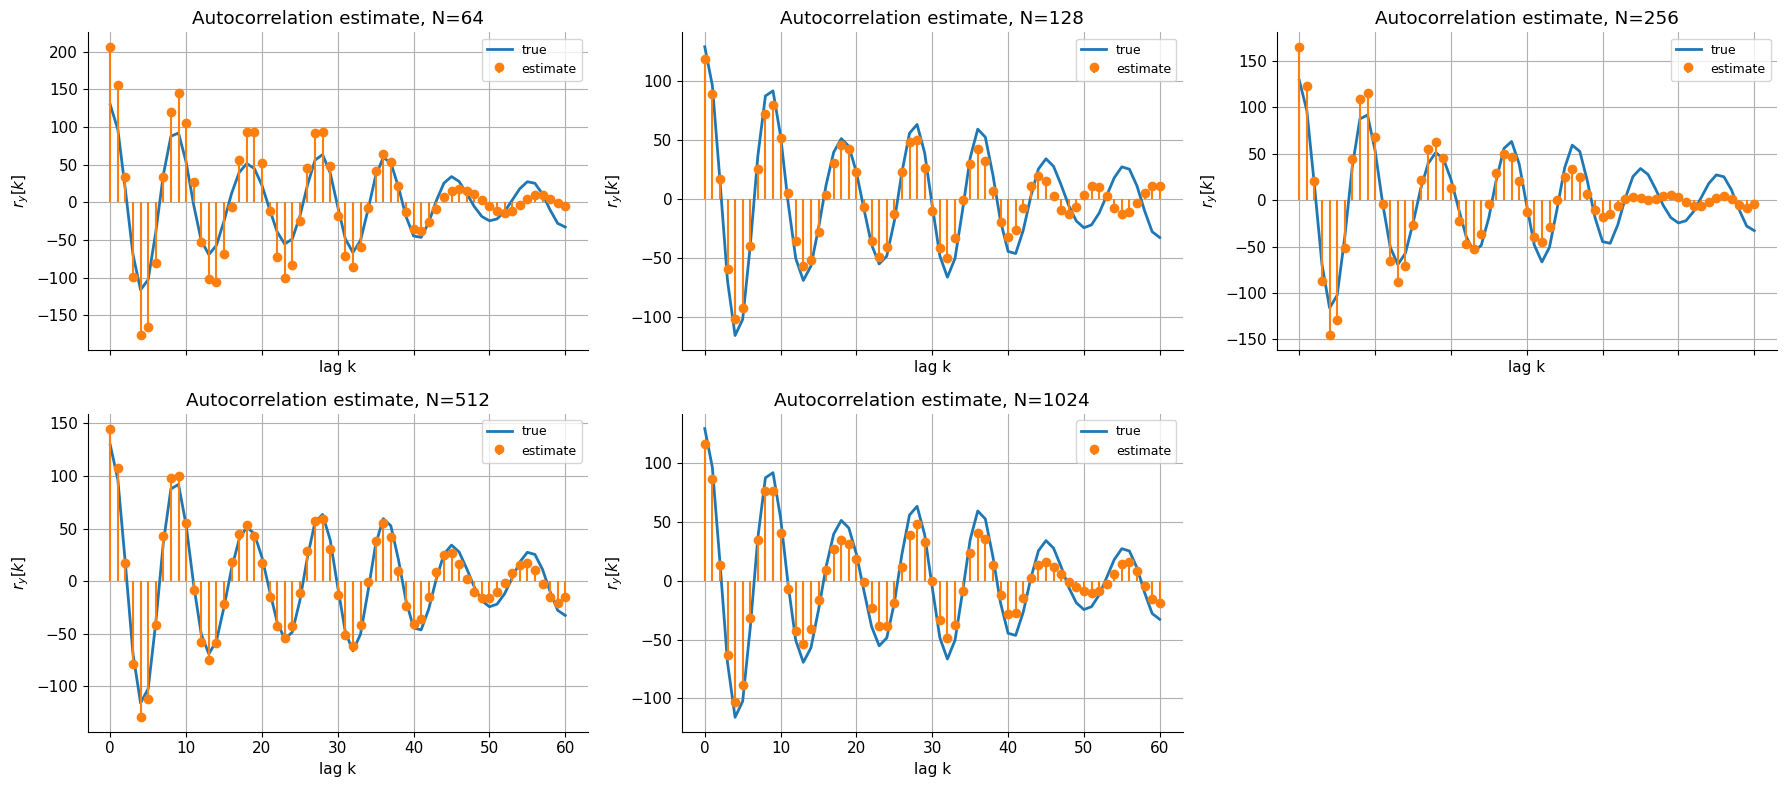

,N,ACF_RMSE_lags_0_to_60
0,64,29.243024
1,128,16.442654
2,256,18.224644
3,512,7.963693
4,1024,11.790278


In [6]:
ACF_MAX_LAG = 60
lags_pos = np.arange(ACF_MAX_LAG + 1)
r_true_pos = true_autocorr_at_lags(lags_pos)

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
axes = axes.ravel()
acf_error_summary = []

for i, N in enumerate(N_VALUES):
    r_hat = sample_autocorr(y_main[:N], ACF_MAX_LAG, unbiased=False)
    err_rmse = np.sqrt(np.mean((r_hat - r_true_pos) ** 2))
    acf_error_summary.append({"N": N, "ACF_RMSE_lags_0_to_60": err_rmse})
    ax = axes[i]
    ax.plot(lags_pos, r_true_pos, label="true", linewidth=2)
    ax.stem(lags_pos, r_hat, linefmt="C1-", markerfmt="C1o", basefmt=" ", label="estimate")
    ax.set_title(f"Autocorrelation estimate, N={N}")
    ax.set_xlabel("lag k")
    ax.set_ylabel(r"$r_y[k]$")
    ax.legend(fontsize=9)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

display(pd.DataFrame(acf_error_summary))


### Comments

- For N=64, the autocorrelation estimate is highly unreliable, with RMSE 29.24 over lags 0 to 60. The plotted stems miss much of the smooth oscillatory shape because there are too few contributing to each lag estimate.
- Increasing the record length generally improves the estimate, and the best RMSE in this realization is 7.96 at N=512. The main improvement is that the low lag peaks and sign changes begin to line up with the curve.
- The error is not monotone: N=1024 has RMSE 11.79, larger than N=512. This does not contradict the theory; it shows that one realization can still produce random deviations, particularly for a long process.
- Larger lags remain harder to estimate because fewer overlapping sample pairs are available and because the biased estimator divides by N.

## (c) True power spectrum

Using the transfer function, the true power spectrum is

$$
S_y(e^{j\omega}) = S_x(e^{j\omega})|H(e^{j\omega})|^2.
$$

Since $x[n]$ is white Gaussian noise with variance 1, $S_x(e^{j\omega})=1$, so

$$
S_y(e^{j\omega}) = \left|\frac{1-0.9e^{-j\omega}+0.81e^{-j2\omega}}
{1-2.76e^{-j\omega}+3.809e^{-j2\omega}-2.654e^{-j3\omega}+0.924e^{-j4\omega}}\right|^2.
$$


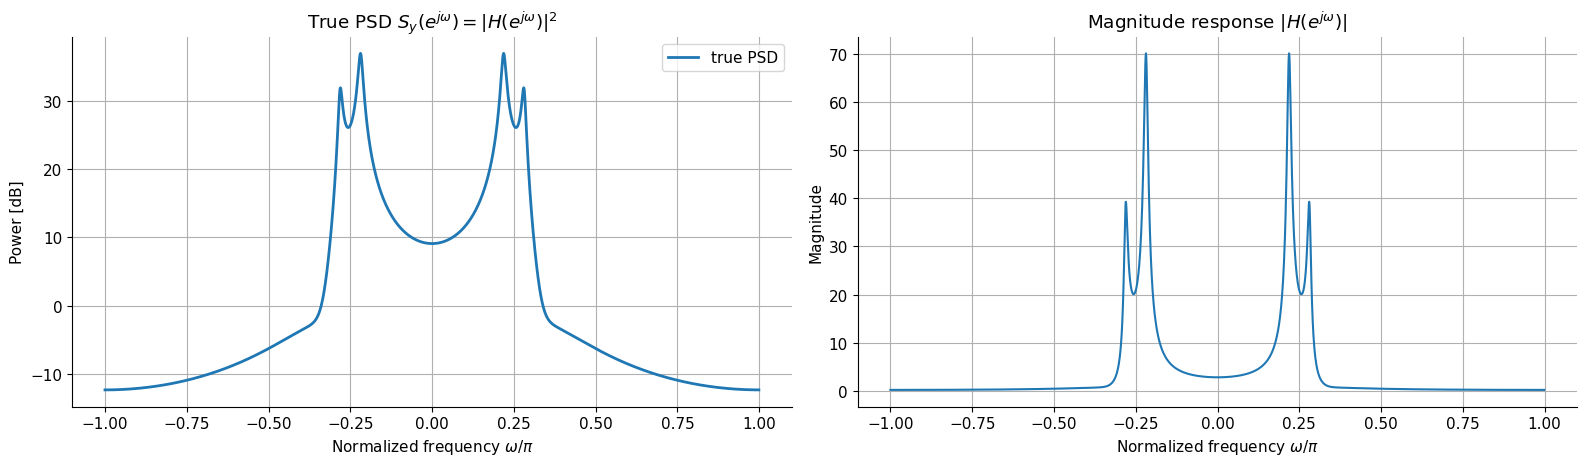

,quantity,value
0,PSD dynamic range in dB,49.192536


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

plot_psd_curve(w_grid, S_true_grid, label="true PSD", ax=axes[0], use_db=True, linewidth=2)
axes[0].set_title(r"True PSD $S_y(e^{j\omega}) = |H(e^{j\omega})|^2$")
axes[0].legend()

axes[1].plot(w_grid / np.pi, np.abs(H_of_w(w_grid)), linewidth=1.5)
axes[1].set_title(r"Magnitude response $|H(e^{j\omega})|$")
axes[1].set_xlabel(r"Normalized frequency $\omega/\pi$")
axes[1].set_ylabel("Magnitude")

plt.tight_layout()
plt.show()

display(pd.DataFrame({"quantity": ["PSD dynamic range in dB"], "value": [float(db(S_true_grid).max() - db(S_true_grid).min())]}))


### Comments

- Since the noise has unit variance and is white, the theoretical PSD is exactly the squared magnitude response.
- The PSD dynamic range is 49.19 dB, which is large for a finite data estimation problem. The process has narrow high power resonances and much lower power frequency regions.
- The sharp peaks come from poles close to the unit circle, while the numerator zeros help shape the valley structures. This frequency selectivity is the spectral version of the slow, oscillatory autocorrelation seen earlier.
- This true PSD is a target: estimators need enough resolution to locate the narrow peaks, but they also need variance reduction so the random fluctuations do not hide the shape.

## (d) Periodogram estimates from the same 1024 sample realization

For a length $N$ segment, the periodogram is

$$
\hat S_y(e^{j\omega})=\frac{1}{N}\left|\sum_{n=0}^{N-1}y[n]e^{-j\omega n}\right|^2.
$$

The same generated 1024 sample sequence is truncated to each requested length.


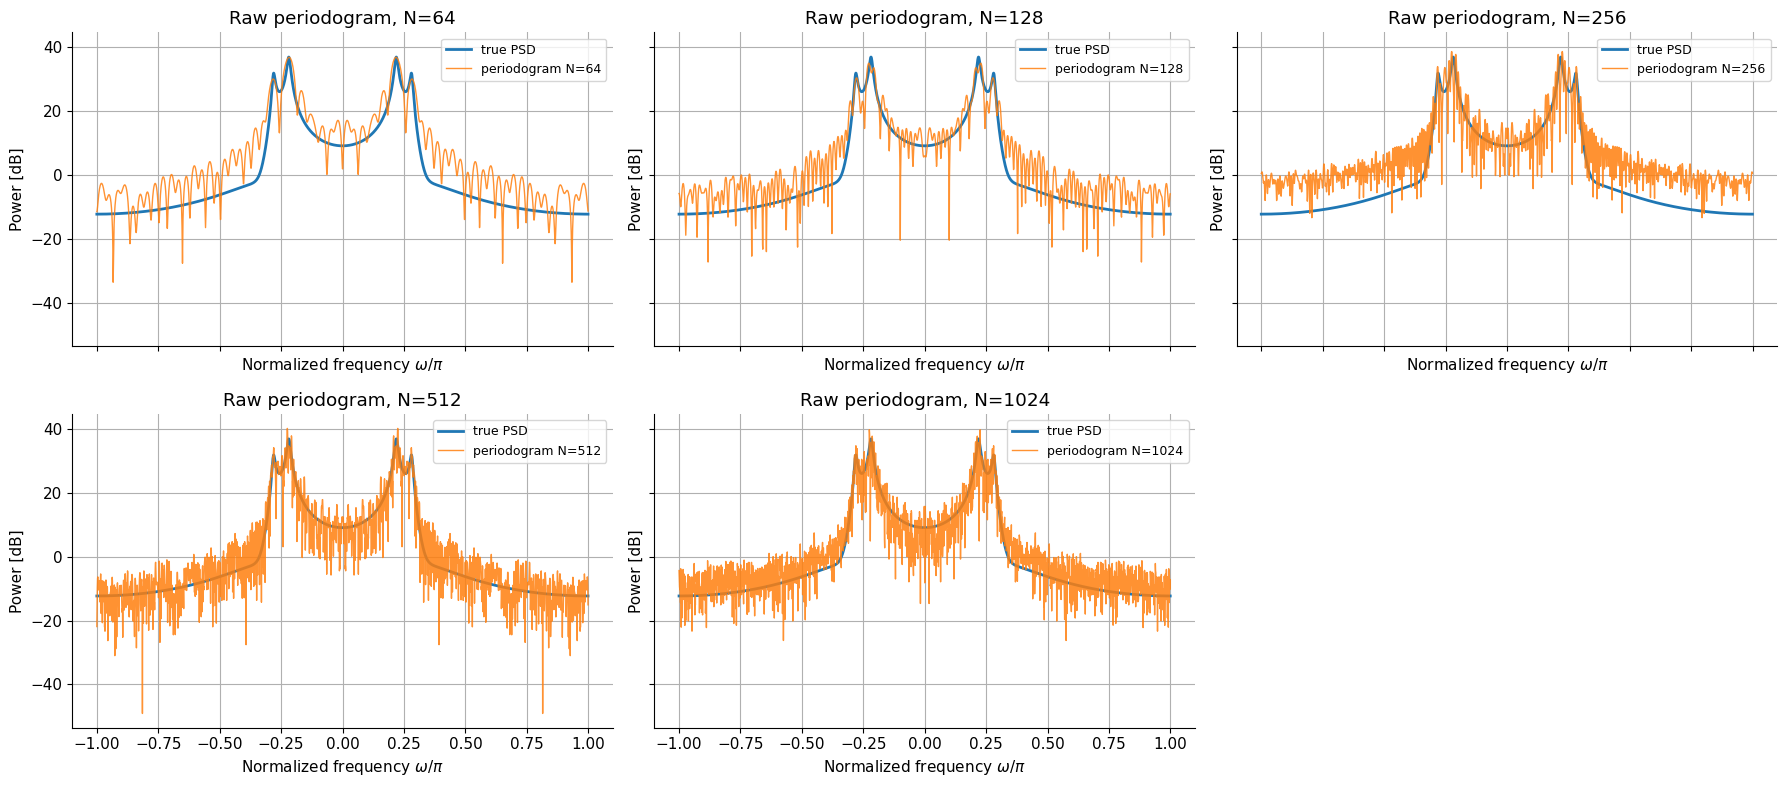

,N,MSE_in_dB_grid
0,64,50.765053
1,128,41.229838
2,256,77.720042
3,512,32.746371
4,1024,29.461189


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.ravel()
periodogram_single_summary = []

for i, N in enumerate(N_VALUES):
    I_N = raw_periodogram(y_main[:N], n_fft=N_FFT)
    mse_db = np.mean((db(I_N) - db(S_true_grid)) ** 2)
    periodogram_single_summary.append({"N": N, "MSE_in_dB_grid": mse_db})
    ax = axes[i]
    plot_psd_curve(w_grid, S_true_grid, "true PSD", ax=ax, use_db=True, linewidth=2)
    plot_psd_curve(w_grid, I_N, f"periodogram N={N}", ax=ax, use_db=True, linewidth=1, alpha=0.85)
    ax.set_title(f"Raw periodogram, N={N}")
    ax.legend(fontsize=9)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

display(pd.DataFrame(periodogram_single_summary))


### Comments

- The  periodogram identifies the broad locations of the strongest spectral peaks, but the curve is dominated by random fluctuations at every data length.
- Increasing N improves frequency resolution because the FFT is based on a longer record, but it does not average away the randomness of a single squared Fourier transform. That is why the estimates remain visually rough even when N=1024.
- The dB grid MSE is not monotone; N=256 is worse than N=128 for this realization. This is an important observation because it shows that a single periodogram should not be judged only by record length.
- The N=1024 periodogram has the lowest error here, but it is still not a reliable smooth PSD estimate. The correct interpretation is that the raw periodogram is useful for locating spectral energy, but not for low variance estimation from one record.

## (e) Statistical behavior of the periodogram

This section generates many independent realizations and computes the sample mean and variance of the periodogram for each requested data length.

Expected behavior:

- The sample mean tends to follow the true spectrum better as the number of trials increases.
- The periodogram variance remains large even when the data length increases; the raw periodogram is not a consistent PSD estimator without additional smoothing or averaging.


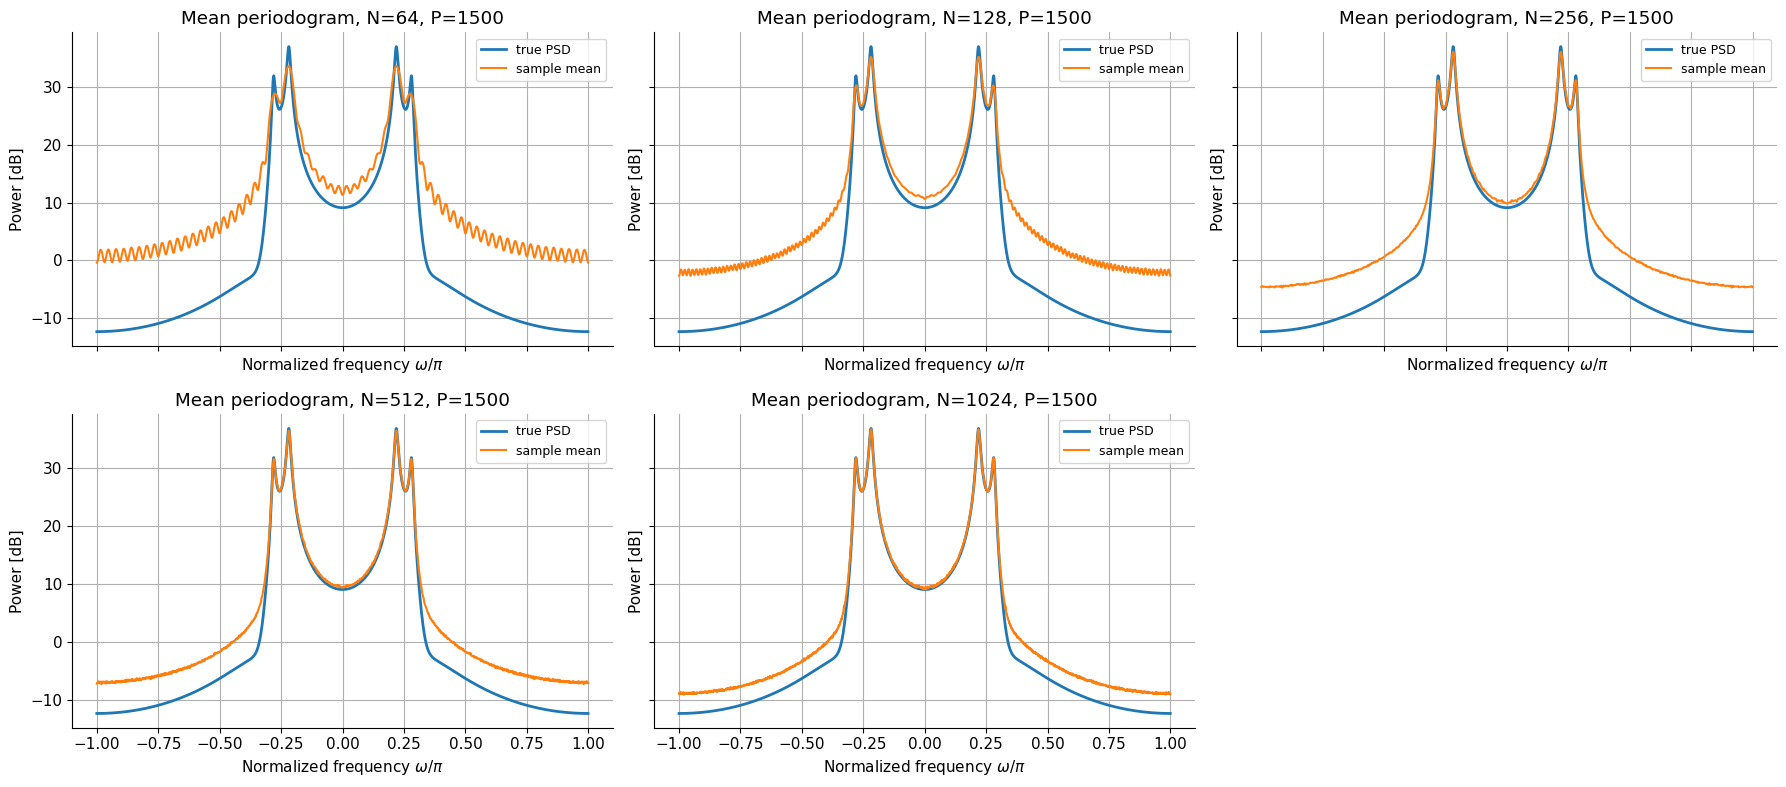

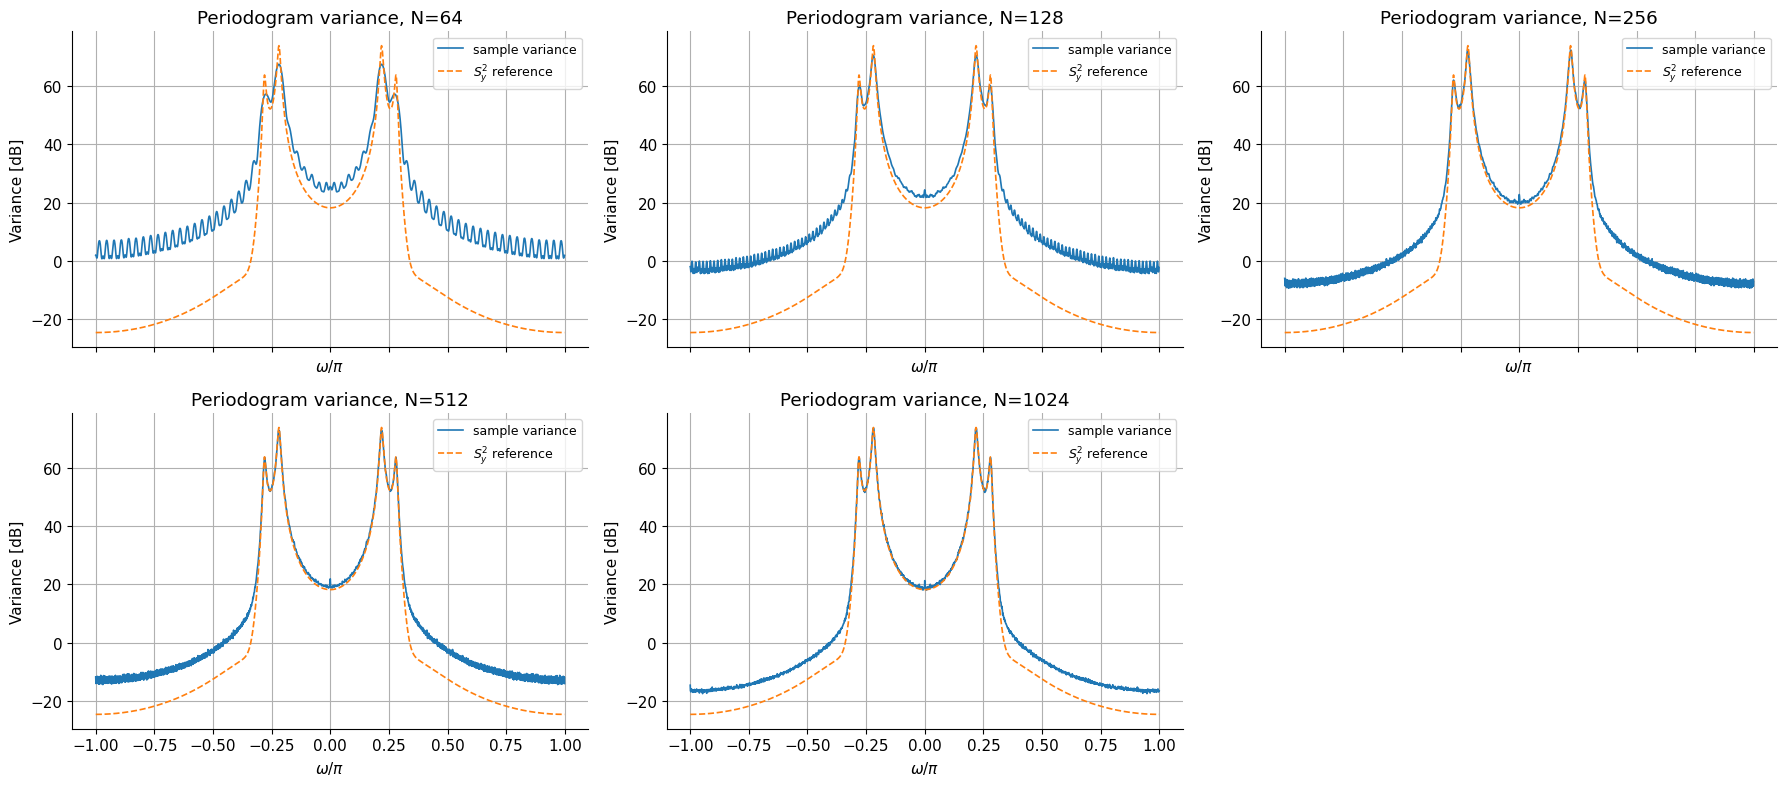

,N,trials,mean_abs_error_dB,average_variance
0,64,1500,9.663342,167968.608680
1,128,1500,7.322034,212054.465751
2,256,1500,5.372408,248120.494662
3,512,1500,3.655317,262845.018363
4,1024,1500,2.337743,286797.953330


In [9]:
rng_mc = np.random.default_rng(SEED + 100)
Y_mc = generate_y_realizations(MC_TRIALS, max(N_VALUES), rng_mc)
period_stats = periodogram_stats(Y_mc, N_VALUES, n_fft=N_FFT)

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.ravel()
period_mc_summary = []

for i, N in enumerate(N_VALUES):
    mean_I = period_stats[N]["mean"]
    var_I = period_stats[N]["var"]
    mean_abs_db_error = np.mean(np.abs(db(mean_I) - db(S_true_grid)))
    avg_variance = np.mean(var_I)
    period_mc_summary.append({
        "N": N,
        "trials": MC_TRIALS,
        "mean_abs_error_dB": mean_abs_db_error,
        "average_variance": avg_variance,
    })
    ax = axes[i]
    plot_psd_curve(w_grid, S_true_grid, "true PSD", ax=ax, use_db=True, linewidth=2)
    plot_psd_curve(w_grid, mean_I, "sample mean", ax=ax, use_db=True, linewidth=1.5)
    ax.set_title(f"Mean periodogram, N={N}, P={MC_TRIALS}")
    ax.legend(fontsize=9)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
axes = axes.ravel()
for i, N in enumerate(N_VALUES):
    ax = axes[i]
    ax.plot(w_grid / np.pi, db(period_stats[N]["var"]), linewidth=1.2, label="sample variance")
    ax.plot(w_grid / np.pi, db(S_true_grid ** 2), linestyle="--", linewidth=1.2, label=r"$S_y^2$ reference")
    ax.set_title(f"Periodogram variance, N={N}")
    ax.set_xlabel(r"$\omega/\pi$")
    ax.set_ylabel("Variance [dB]")
    ax.legend(fontsize=9)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

display(pd.DataFrame(period_mc_summary))


### Comments

- With 1500 independent realizations, the sample mean periodogram follows the true PSD much more closely than any single realization. The mean absolute error drops from 9.66 dB at N=64 to 2.34 dB at N=1024.
- The variance plot is the key result for this question. The variance remains large and does not collapse toward zero as N increases, which matches the known behavior of the raw periodogram.
- In the theoretical mean expression for this periodogram, the smoothing kernel is the Bartlet window caused by observing only N samples.
- The average variance increases from about 1.68e5 to 2.87e5 in this experiment because longer records resolve the high power peaks more sharply; variance is largest where the true spectrum is largest.
- Averaging over realizations improves our estimate of the expected periodogram, but it does not make an individual periodogram consistent. The experiment therefore confirms the theory: the periodogram is approximately unbiased in the limit, but its variance remains on the order of the squared PSD.

## (f) Welch periodogram estimate

Welch's method divides the sequence into overlapping segments, windows each segment, computes one modified periodogram per segment, and averages them:

$$
\hat S_{Welch}(e^{j\omega}) = \frac{1}{K}\sum_{k=1}^{K}\frac{1}{\sum_n w^2[n]}
\left|\sum_n w[n]y_k[n]e^{-j\omega n}\right|^2.
$$

Here I use a Hann window with 50% overlap. This reduces variance by averaging, but it can smooth sharp spectral features.


,N,Ns_segment_length,R_overlap,step,K_segments,window
0,64,32,16,16,3,hann
1,128,64,32,32,3,hann
2,256,128,64,64,3,hann
3,512,256,128,128,3,hann
4,1024,256,128,128,7,hann


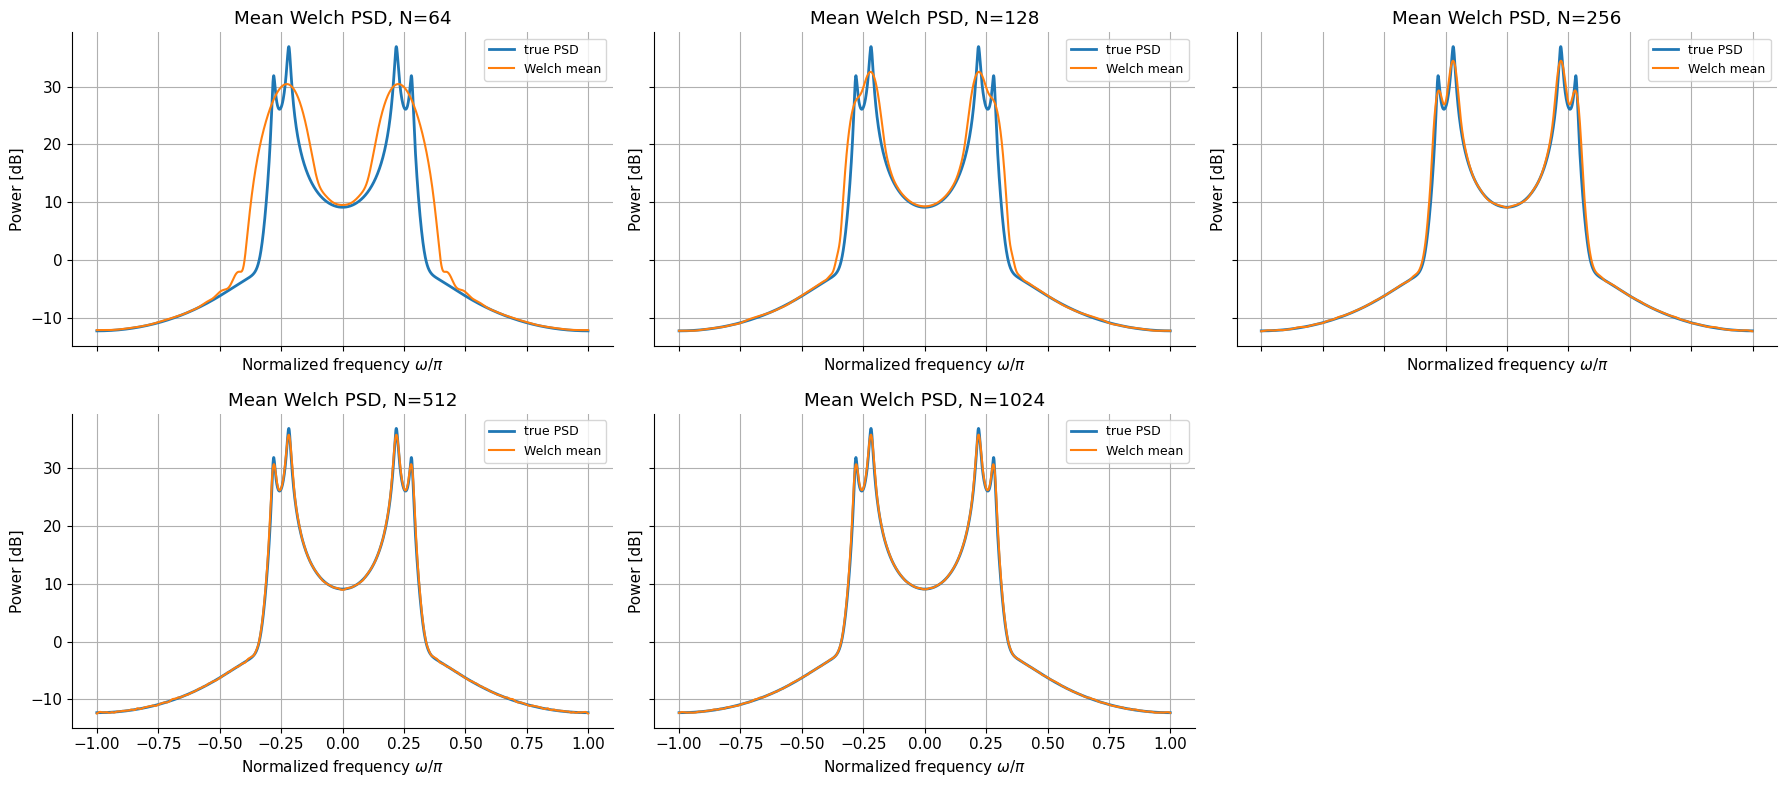

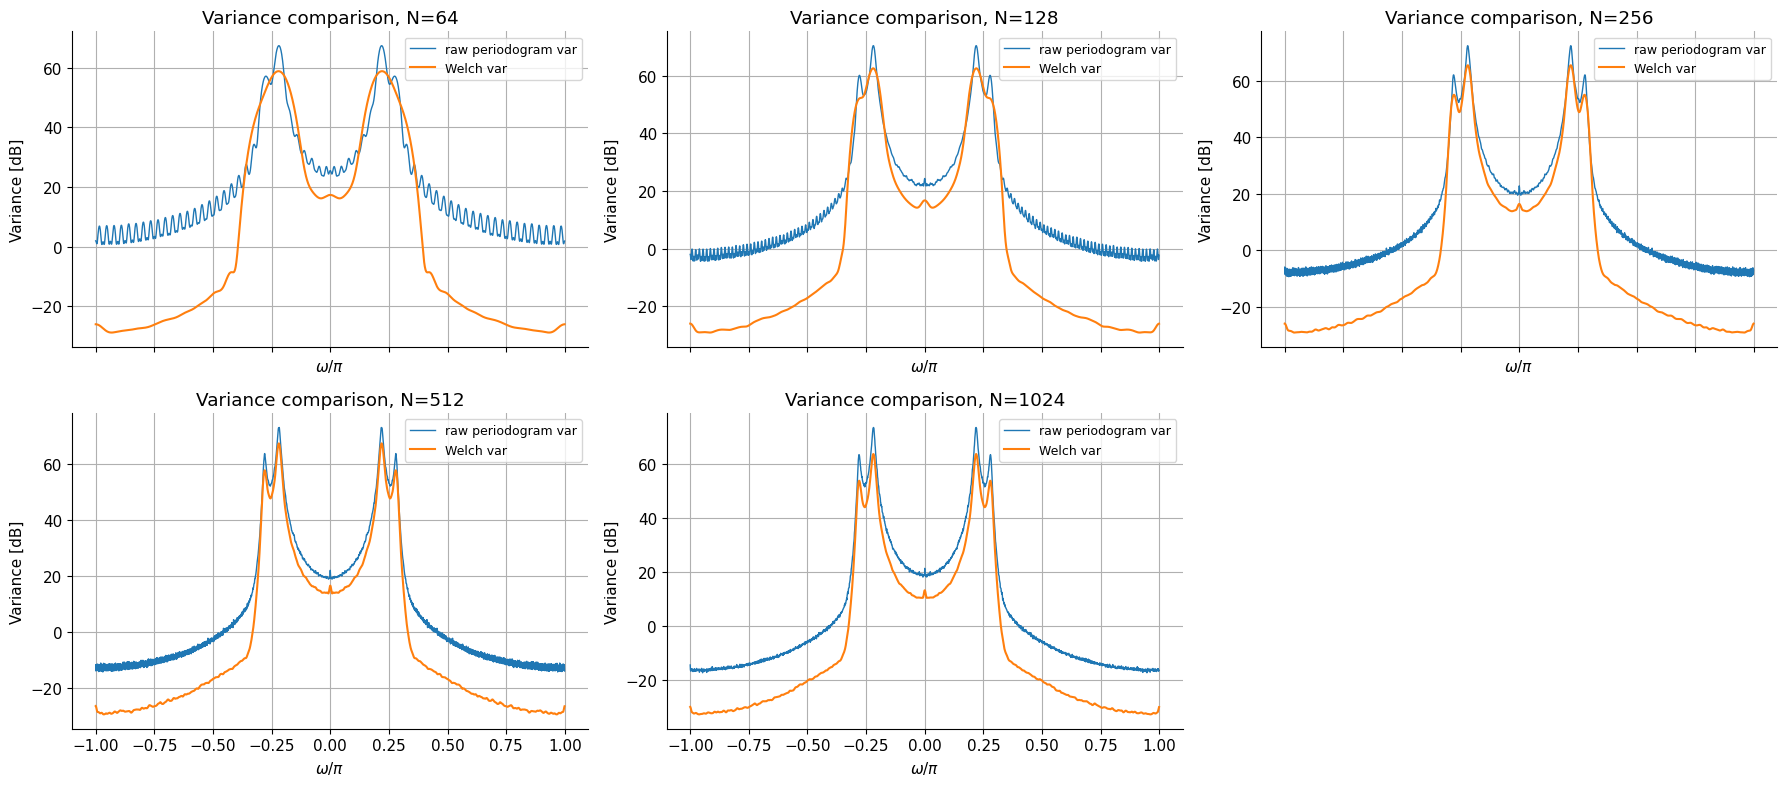

,N,K_segments,segment_length,mean_abs_error_dB,average_variance_Welch,average_variance_raw_periodogram,variance_ratio_Welch_over_raw
0,64,3,32,2.570666,58984.796497,167968.608680,0.351166
1,128,3,64,1.052193,77303.315995,212054.465751,0.364545
2,256,3,128,0.382912,84462.048816,248120.494662,0.340407
3,512,3,256,0.144824,88992.406882,262845.018363,0.338574
4,1024,7,256,0.132735,39690.822066,286797.953330,0.138393


In [10]:
welch_param_table = pd.DataFrame([default_welch_params(N) for N in N_VALUES])
display(welch_param_table)

welch_mc_stats = welch_stats(Y_mc, N_VALUES, n_fft=N_FFT)

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.ravel()
welch_summary = []

for i, N in enumerate(N_VALUES):
    mean_W = welch_mc_stats[N]["mean"]
    var_W = welch_mc_stats[N]["var"]
    mean_abs_db_error = np.mean(np.abs(db(mean_W) - db(S_true_grid)))
    avg_variance = np.mean(var_W)
    avg_raw_variance = np.mean(period_stats[N]["var"])
    welch_summary.append({
        "N": N,
        "K_segments": welch_mc_stats[N]["params"]["K_segments"],
        "segment_length": welch_mc_stats[N]["params"]["Ns_segment_length"],
        "mean_abs_error_dB": mean_abs_db_error,
        "average_variance_Welch": avg_variance,
        "average_variance_raw_periodogram": avg_raw_variance,
        "variance_ratio_Welch_over_raw": avg_variance / avg_raw_variance,
    })
    ax = axes[i]
    plot_psd_curve(w_grid, S_true_grid, "true PSD", ax=ax, use_db=True, linewidth=2)
    plot_psd_curve(w_grid, mean_W, "Welch mean", ax=ax, use_db=True, linewidth=1.5)
    ax.set_title(f"Mean Welch PSD, N={N}")
    ax.legend(fontsize=9)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
axes = axes.ravel()
for i, N in enumerate(N_VALUES):
    ax = axes[i]
    ax.plot(w_grid / np.pi, db(period_stats[N]["var"]), linewidth=1.0, label="raw periodogram var")
    ax.plot(w_grid / np.pi, db(welch_mc_stats[N]["var"]), linewidth=1.5, label="Welch var")
    ax.set_title(f"Variance comparison, N={N}")
    ax.set_xlabel(r"$\omega/\pi$")
    ax.set_ylabel("Variance [dB]")
    ax.legend(fontsize=9)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

display(pd.DataFrame(welch_summary))


### Comments

- Welch's method gives the expected bias variance tradeoff: it averages several windowed segment periodograms, so the estimate is much less variable than the periodogram.
- The variance reduction is substantial. The Welch to raw variance ratio is about 0.34 to 0.36 for N=64 through N=512, and improves to 0.138 at N=1024 because seven segments are available.
- The mean error is also much smaller, reaching 0.133 dB at N=1024. This shows that, for this process and these parameters, the variance reduction more than compensates for the smoothing bias.
- The price for the reduced frequency resolution: the shorter segments smooth narrow resonanting features. This is expected behavior here because the goal is a stable PSD estimate.

# Part II Deep Learning Based Power Spectrum Estimation

We train neural networks to learn the mapping

$$
y_{ML}[n] = f_\theta(x[n],x[n-1],\dots,x[n-P]) \approx y[n].
$$

The same alignment as the provided training scripts is used:

1. `x_store[0]` corresponds to conceptual $x[-P]$.
2. `x_store[P]` corresponds to conceptual $x[0]$.
3. The model input for $y[n]$ is `[x_store[n+P], x_store[n+P-1], ..., x_store[n]]`.

Since the true system has a long impulse response, a larger `P` gives the network access to more of the input history.


In [11]:

class SimpleMLP(nn.Module):
    """MLP model for lag window regression."""
    def __init__(self, P: int, hidden: int = 64, num_hidden_layers: int = 2):
        """Create model layers."""
        super().__init__()
        layers = []
        d = P + 1
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(d, hidden))
            layers.append(nn.ReLU(inplace=True))
            d = hidden
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)
        self.P = P
        self.hidden = hidden
        self.num_hidden_layers = num_hidden_layers

    def forward(self, x):
        """Evaluate the model."""
        return self.net(x).squeeze(-1)


class SimpleLSTM(nn.Module):
    """LSTM model for lag window regression."""
    def __init__(self, P: int, hidden: int = 64, num_layers: int = 1):
        """Create model layers."""
        super().__init__()
        self.P = P
        self.hidden = hidden
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        """Evaluate the model."""
        seq = x.unsqueeze(-1)
        out, _ = self.lstm(seq)
        last = out[:, -1, :]
        return self.head(last).squeeze(-1)


def make_windows_np(x_store: np.ndarray, y: np.ndarray, P: int) -> tuple[np.ndarray, np.ndarray]:
    """Build lag window features for training."""
    x_store = np.asarray(x_store, dtype=np.float32).reshape(-1)
    y = np.asarray(y, dtype=np.float32).reshape(-1)
    N = len(y)
    n = np.arange(N)
    X = np.stack([x_store[n + P - lag] for lag in range(P + 1)], axis=1)
    return X.astype(np.float32), y.astype(np.float32)


def make_windows_batch_np(x_batch: np.ndarray, P: int) -> np.ndarray:
    """Build lag window features for batched inference."""
    x_batch = np.asarray(x_batch, dtype=np.float32)
    B, total_len = x_batch.shape
    N = total_len - P
    n = np.arange(N)
    X = np.stack([x_batch[:, n + P - lag] for lag in range(P + 1)], axis=2)
    return X.astype(np.float32)


def train_torch_model(
    model,
    X: np.ndarray,
    y: np.ndarray,
    *,
    epochs: int,
    lr: float,
    batch_size: int = 0,
    val_fraction: float = 0.2,
    seed: int = SEED,
):
    """Train a model and return history."""
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    total = len(dataset)
    val_count = max(1, int(round(val_fraction * total)))
    train_count = total - val_count
    generator = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset = random_split(dataset, [train_count, val_count], generator=generator)
    train_batch_size = train_count if batch_size <= 0 else min(batch_size, train_count)
    val_batch_size = val_count if batch_size <= 0 else min(batch_size, val_count)
    train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=train_batch_size < train_count, drop_last=False)
    val_loader = DataLoader(val_dataset, batch_size=val_batch_size, shuffle=False, drop_last=False)

    target = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(target)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    crit_sum = nn.MSELoss(reduction="sum")
    history = {"epoch": [], "train_mse": [], "val_mse": []}
    best_state = None
    best_val_mse = float("inf")

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        batches = 0
        stop_training = False
        for xb, yb in train_loader:
            xb = xb.to(target)
            yb = yb.to(target)
            opt.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = crit(pred, yb)
            if bool(torch.isfinite(loss).detach().cpu()):
                loss.backward()
                opt.step()
                running += float(loss.detach().cpu())
                batches += 1
            else:
                running = float("inf")
                batches = max(batches, 1)
                stop_training = True
                break

        model.eval()
        val_total = 0.0
        val_seen = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(target)
                yb = yb.to(target)
                pred = model(xb)
                val_total += float(crit_sum(pred, yb).detach().cpu())
                val_seen += int(yb.numel())
        train_mse = running / max(batches, 1)
        val_mse = val_total / max(val_seen, 1)
        train_mse = float(train_mse) if np.isfinite(train_mse) else float("inf")
        val_mse = float(val_mse) if np.isfinite(val_mse) else float("inf")
        history["epoch"].append(epoch)
        history["train_mse"].append(train_mse)
        history["val_mse"].append(val_mse)
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state = deepcopy(model.state_dict())
        if stop_training:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def predict_torch_model(model, X: np.ndarray, batch: int = 65536) -> np.ndarray:
    """Run batched model prediction."""
    target = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(target)
    model.eval()
    preds = []
    with torch.no_grad():
        for start in range(0, len(X), batch):
            xb = torch.tensor(X[start : start + batch], dtype=torch.float32).to(target)
            preds.append(model(xb).detach().cpu().numpy())
    return np.concatenate(preds, axis=0).astype(np.float32)


def infer_y_from_x_batch(model, x_batch: np.ndarray, P: int) -> np.ndarray:
    """Infer output realizations from input batches."""
    Xb = make_windows_batch_np(x_batch, P)
    B, N, D = Xb.shape
    yhat = predict_torch_model(model, Xb.reshape(B * N, D))
    return yhat.reshape(B, N).astype(np.float32)



## (a) Search MLP and LSTM configurations

This cell runs the configuration search used for the neural models. It varies hidden size, layer count, learning rate, and P, then shows the MLP and LSTM train and validation loss panels. The green border marks the selected best configuration for each model family.


,model_type,P,hidden,layer_count,learning_rate,epochs,final_train_mse,final_val_mse,best_val_mse,best_epoch,seconds
0,MLP,160,512,0,0.05,600,0.110952,0.154741,0.154234,133,5.534404
1,LSTM,64,32,3,0.005,600,4.153107,7.629173,3.786903,587,6.479399


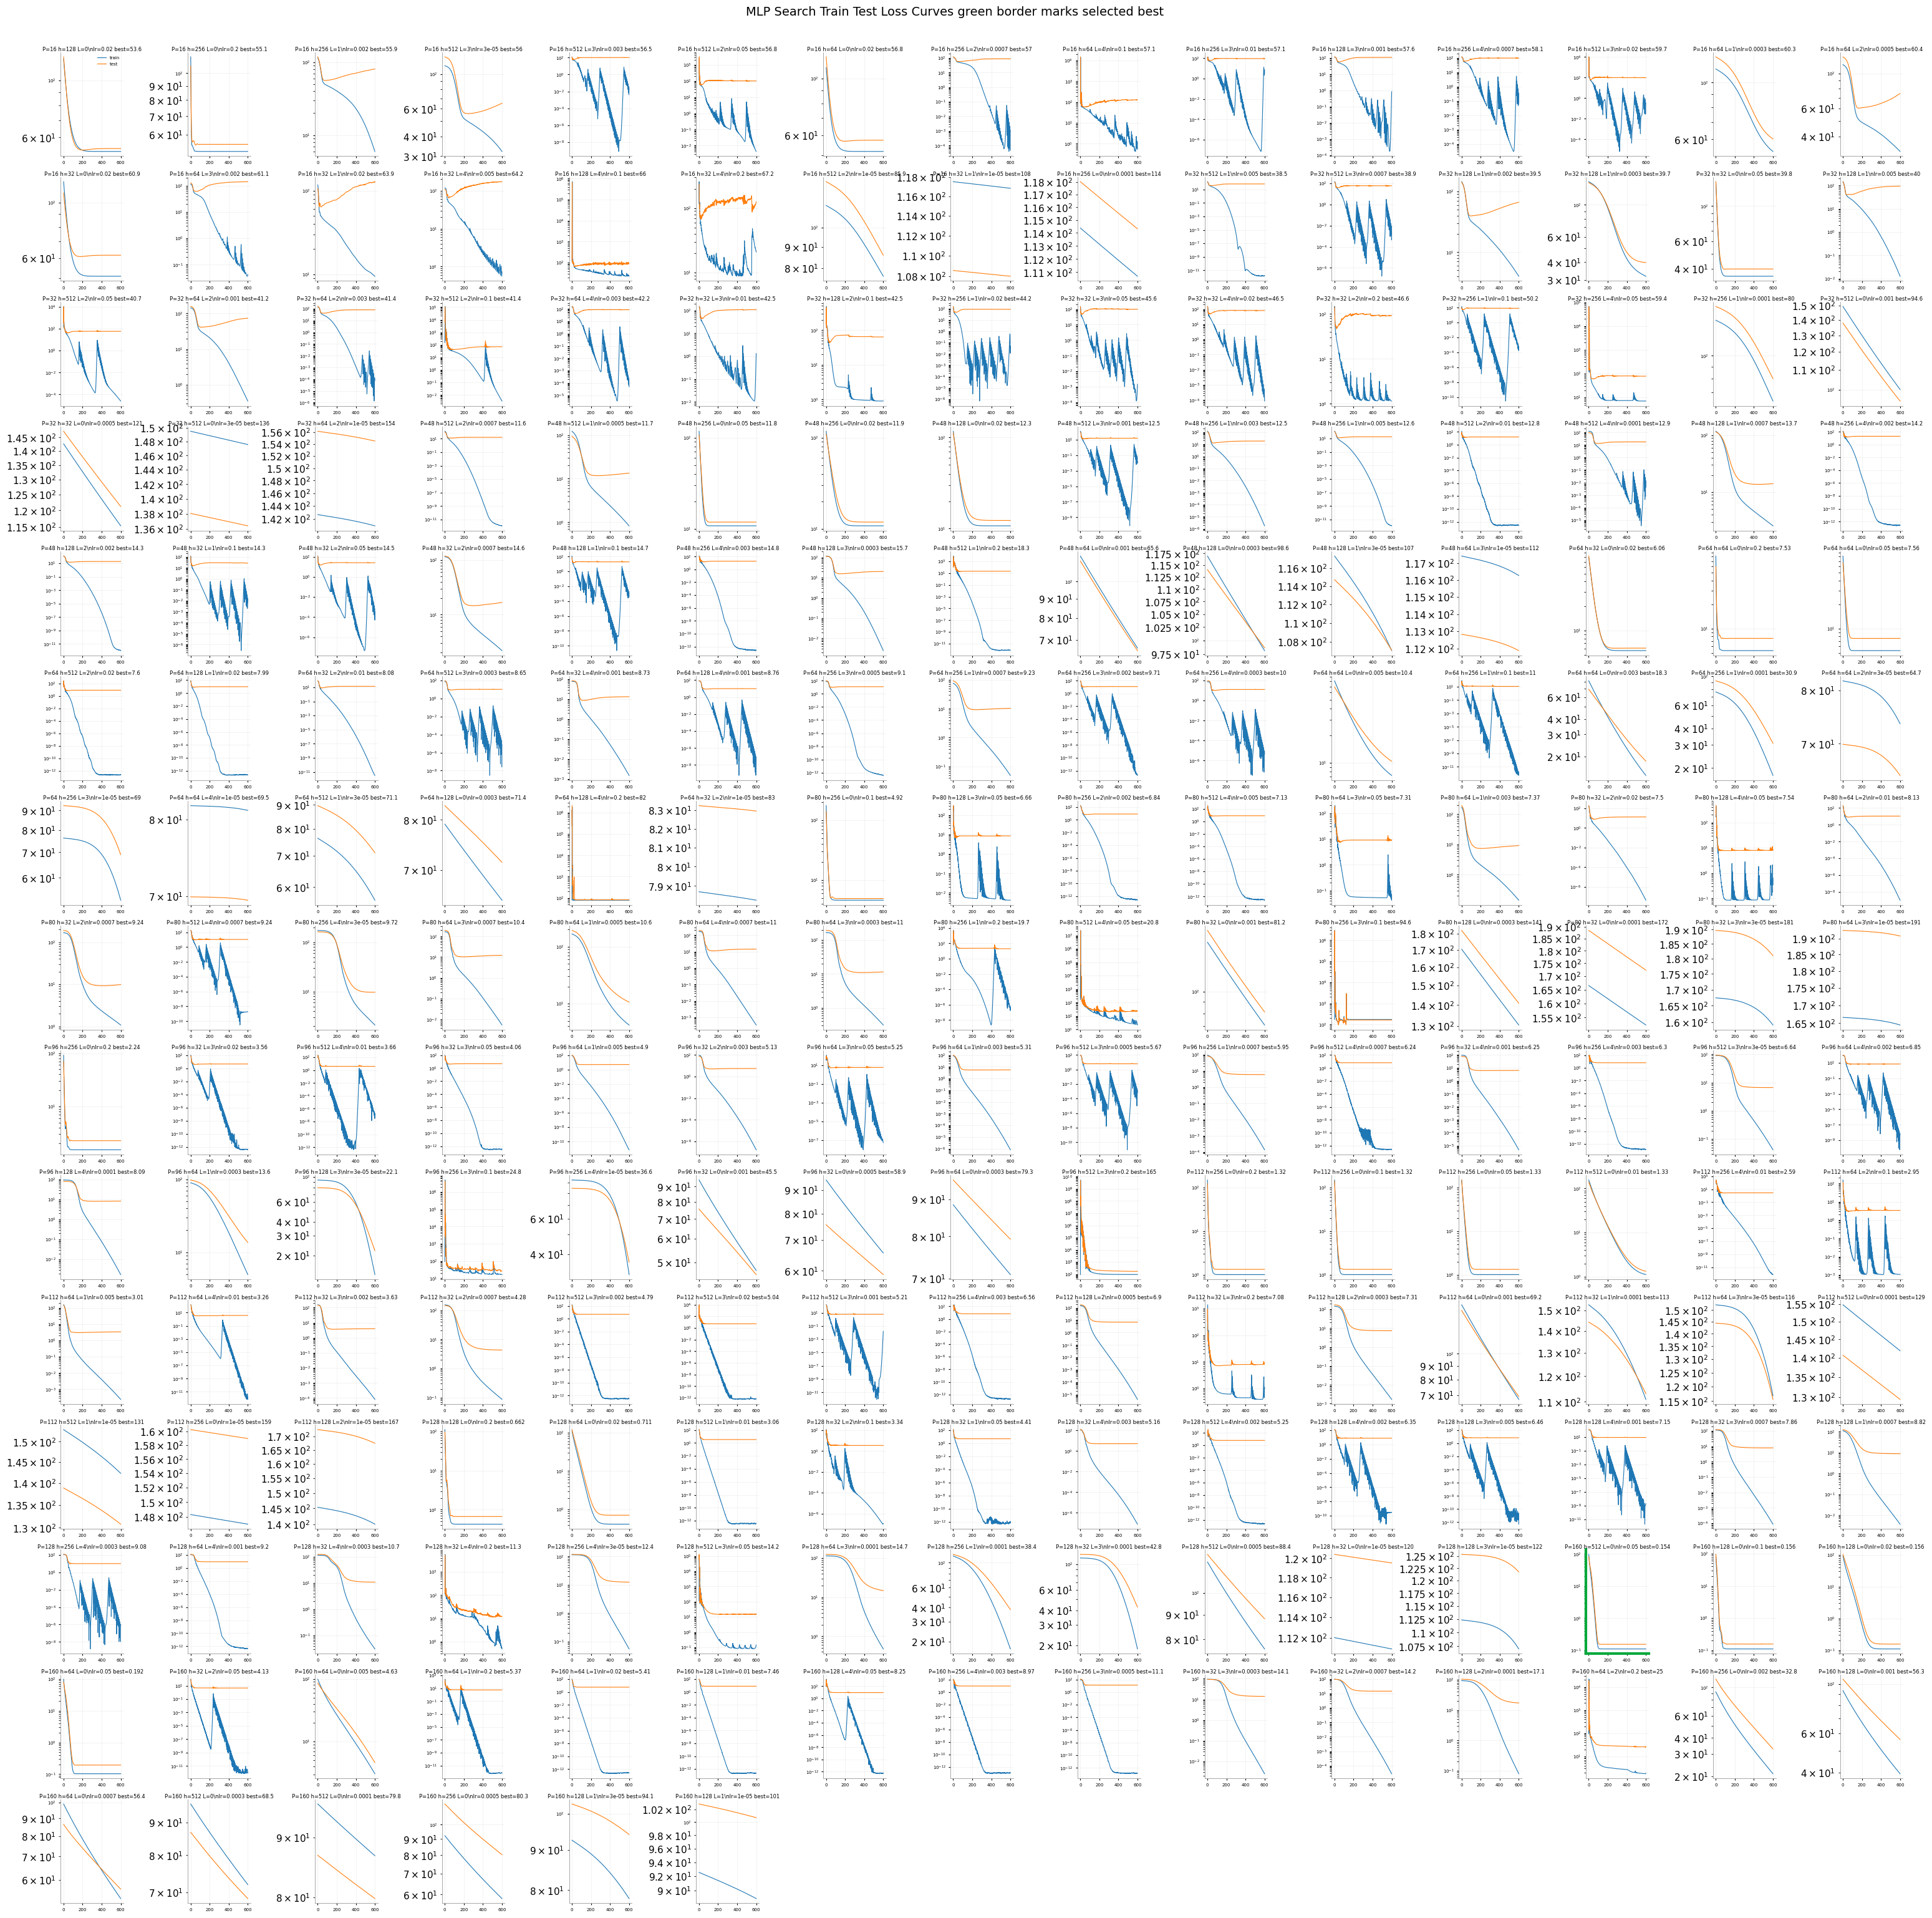

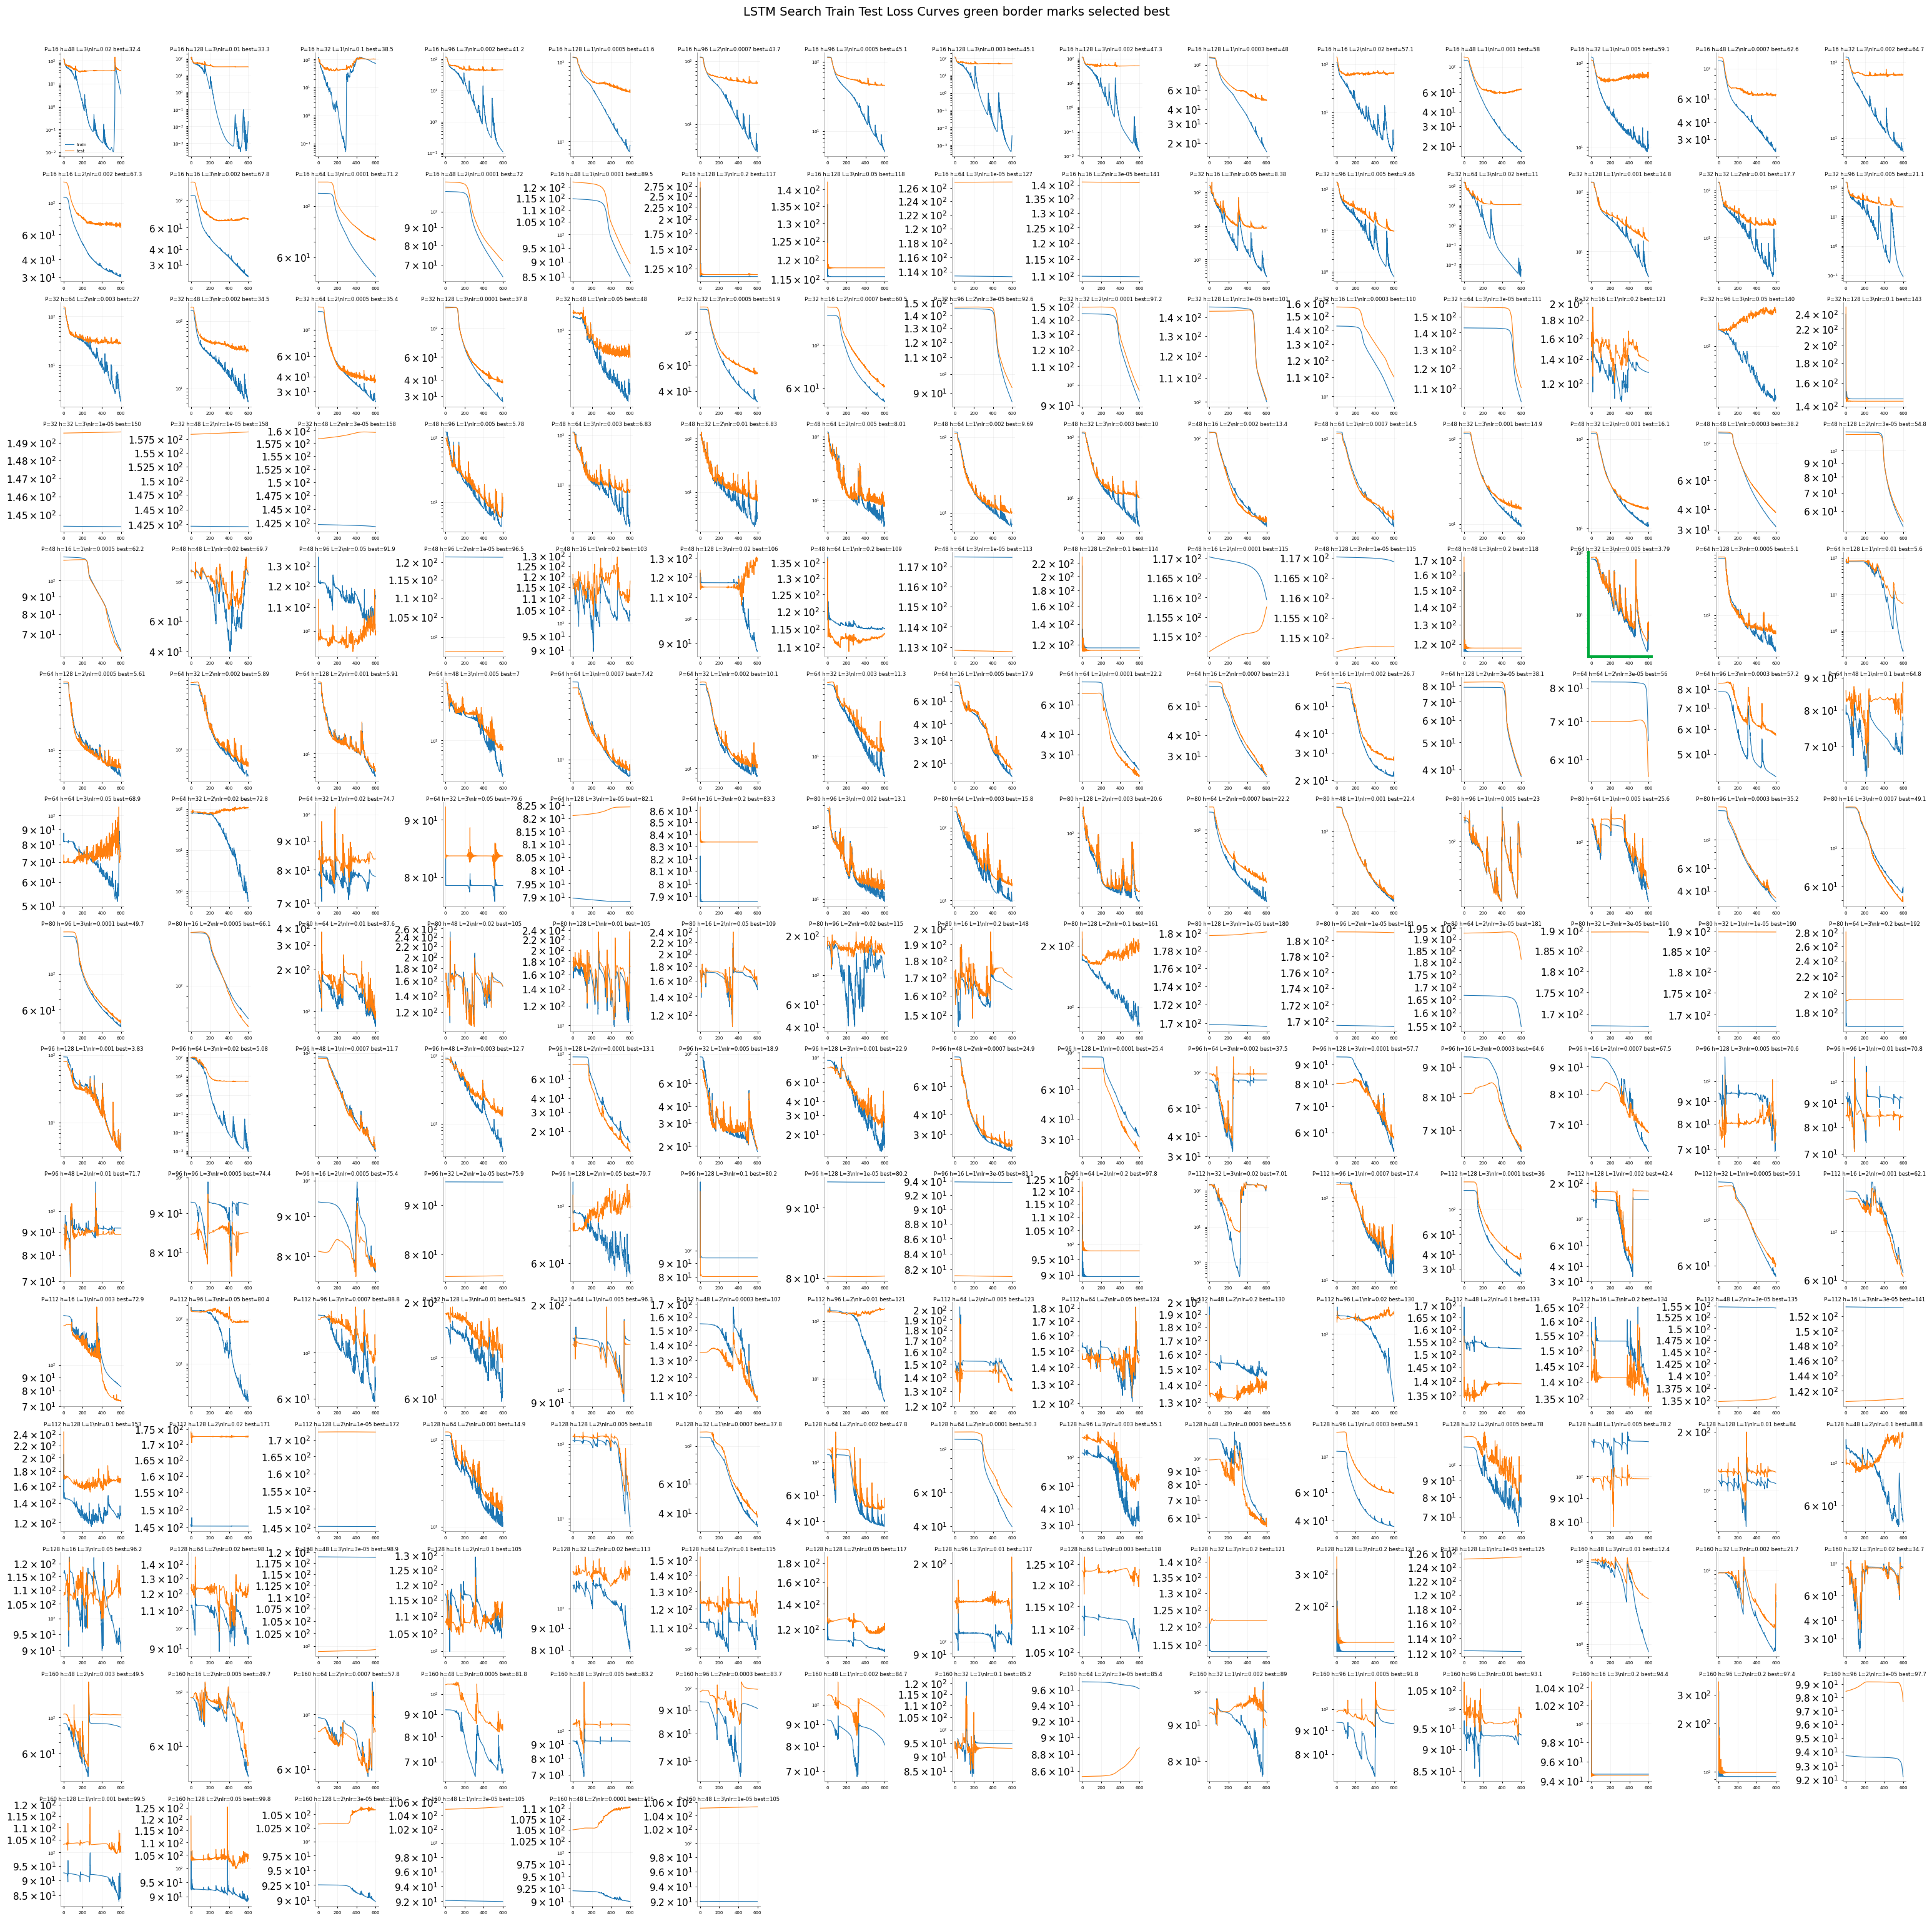

In [12]:

SEARCH_RANDOM_SEED = 25101
SEARCH_TEST_FRACTION = 0.2
MAX_TRIALS_PER_LAG = 24
SEARCH_LEARNING_RATES = [0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.003, 0.002, 0.001, 0.0007, 0.0005, 0.0003, 0.0001, 0.00003, 0.00001]
SEARCH_MLP_HIDDEN = [32, 64, 128, 256, 512]
SEARCH_MLP_LAYERS = [0, 1, 2, 3, 4]
SEARCH_LSTM_HIDDEN = [16, 32, 48, 64, 96, 128]
SEARCH_LSTM_LAYERS = [1, 2, 3]
SEARCH_MODEL_TYPES = ["MLP", "LSTM"]

search_mlp_trials = [
    {"model_type": "MLP", "hidden": int(hidden), "layer_count": int(layer_count), "learning_rate": float(learning_rate)}
    for hidden, layer_count, learning_rate in itertools.product(SEARCH_MLP_HIDDEN, SEARCH_MLP_LAYERS, SEARCH_LEARNING_RATES)
]
search_lstm_trials = [
    {"model_type": "LSTM", "hidden": int(hidden), "layer_count": int(layer_count), "learning_rate": float(learning_rate)}
    for hidden, layer_count, learning_rate in itertools.product(SEARCH_LSTM_HIDDEN, SEARCH_LSTM_LAYERS, SEARCH_LEARNING_RATES)
]
search_trial_grids = {"MLP": search_mlp_trials, "LSTM": search_lstm_trials}
search_model_offsets = {"MLP": 0, "LSTM": 1}
search_model_builders = {
    "MLP": lambda P, cfg: SimpleMLP(P=P, hidden=int(cfg["hidden"]), num_hidden_layers=int(cfg["layer_count"])),
    "LSTM": lambda P, cfg: SimpleLSTM(P=P, hidden=int(cfg["hidden"]), num_layers=int(cfg["layer_count"])),
}


def select_trial_subset(trials: list[dict], P: int, model_offset: int) -> list[dict]:
    """Select a deterministic search subset for one P."""
    rng_search = np.random.default_rng(SEARCH_RANDOM_SEED + 1009 * P + model_offset)
    selected_indices = set()
    for learning_rate in sorted({trial["learning_rate"] for trial in trials}, reverse=True):
        candidates = [index for index, trial in enumerate(trials) if trial["learning_rate"] == learning_rate]
        selected_indices.add(int(rng_search.choice(candidates)))
    remaining = [index for index in range(len(trials)) if index not in selected_indices]
    extra_count = max(0, min(MAX_TRIALS_PER_LAG - len(selected_indices), len(remaining)))
    extra_indices = rng_search.choice(remaining, size=extra_count, replace=False)
    selected_indices.update(int(index) for index in np.atleast_1d(extra_indices))
    return [trials[index] for index in sorted(selected_indices)[:MAX_TRIALS_PER_LAG]]


def train_search_trial(model_type: str, P: int, cfg: dict, X_search: np.ndarray, y_search: np.ndarray, seed: int) -> dict:
    """Train one search trial and summarize its loss curve."""
    torch.manual_seed(seed)
    model = search_model_builders[model_type](P, cfg)
    t0 = time.perf_counter()
    model, history = train_torch_model(
        model,
        X_search,
        y_search,
        epochs=DL_EPOCHS_SEARCH,
        lr=float(cfg["learning_rate"]),
        batch_size=DL_BATCH_SIZE,
        val_fraction=SEARCH_TEST_FRACTION,
        seed=seed,
    )
    elapsed = time.perf_counter() - t0
    val_values = history["val_mse"].to_numpy(dtype=float)
    train_values = history["train_mse"].to_numpy(dtype=float)
    clean_val_values = np.where(np.isfinite(val_values), val_values, np.inf)
    best_index = int(np.argmin(clean_val_values))
    result = {
        "model_type": model_type,
        "P": int(P),
        "hidden": int(cfg["hidden"]),
        "layer_count": int(cfg["layer_count"]),
        "learning_rate": float(cfg["learning_rate"]),
        "epochs": int(len(history)),
        "final_train_mse": float(train_values[-1]) if np.isfinite(train_values[-1]) else float("inf"),
        "final_val_mse": float(val_values[-1]) if np.isfinite(val_values[-1]) else float("inf"),
        "best_val_mse": float(clean_val_values[best_index]),
        "best_epoch": int(history["epoch"].iloc[best_index]),
        "seconds": float(elapsed),
        "history": history,
    }
    return result


def plot_search_loss_panel(model_type: str, search_records: list[dict], selected_config: dict):
    """Draw all search loss curves for one model family."""
    rows = [row for row in search_records if row["model_type"] == model_type]
    rows = sorted(rows, key=lambda row: (int(row["P"]), float(row["best_val_mse"]), int(row["hidden"]), float(row["learning_rate"])))
    n_cols = max(1, math.ceil(math.sqrt(len(rows))))
    n_rows = math.ceil(len(rows) / n_cols)
    cell_size = 2.05
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(max(6, n_cols * cell_size), max(4, n_rows * cell_size)), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for index, row in enumerate(rows):
        ax = axes[index // n_cols][index % n_cols]
        history = row["history"]
        ax.axis("on")
        ax.plot(history["epoch"], history["train_mse"], linewidth=0.8, label="train", color="#1f77b4")
        ax.plot(history["epoch"], history["val_mse"], linewidth=0.8, label="test", color="#ff7f0e")
        ax.set_yscale("log")
        ax.tick_params(axis="both", labelsize=5, length=2)
        ax.grid(True, alpha=0.25, linewidth=0.4)
        ax.set_title(f"P={row['P']} h={row['hidden']} L={row['layer_count']}\\nlr={row['learning_rate']} best={row['best_val_mse']:.3g}", fontsize=6, pad=2)
        for spine in ax.spines.values():
            spine.set_linewidth(0.6)
            spine.set_edgecolor("#999999")
        selected_match = (
            int(row["P"]) == int(selected_config["P"])
            and int(row["hidden"]) == int(selected_config["hidden"])
            and int(row["layer_count"]) == int(selected_config["layer_count"])
            and float(row["learning_rate"]) == float(selected_config["learning_rate"])
        )
        if selected_match:
            for spine in ax.spines.values():
                spine.set_linewidth(3.0)
                spine.set_edgecolor("#00a83b")
        if index == 0:
            ax.legend(fontsize=5, loc="best", frameon=False)
    fig.suptitle(f"{model_type} Search Train Test Loss Curves green border marks selected best", fontsize=14, y=0.999)
    fig.tight_layout(rect=(0, 0, 1, 0.995), h_pad=0.65, w_pad=0.35)
    plt.show()
    return fig


search_records = []
search_training_data = {}

for P_LAG in P_VALUES_TO_TEST:
    rng_lag = np.random.default_rng(NEURAL_PROJECT_SEED + P_LAG)
    x_lag, y_lag = generate_xy_pair(N_MAIN, P_LAG, rng_lag)
    X_lag, y_lag = make_windows_np(x_lag, y_lag, P_LAG)
    search_training_data[P_LAG] = {"x": x_lag, "X": X_lag, "y": y_lag}
    for model_type in SEARCH_MODEL_TYPES:
        selected_trials = select_trial_subset(search_trial_grids[model_type], P_LAG, search_model_offsets[model_type])
        for trial_index, cfg in enumerate(selected_trials):
            seed_trial = NEURAL_PROJECT_SEED + P_LAG + int(cfg["hidden"])
            search_records.append(train_search_trial(model_type, P_LAG, cfg, X_lag, y_lag, seed_trial))

search_results_df = pd.DataFrame([{key: value for key, value in row.items() if key != "history"} for row in search_records])
search_results_df = search_results_df.sort_values(["model_type", "P", "best_val_mse"]).reset_index(drop=True)

selected_configs = {}
for model_type in SEARCH_MODEL_TYPES:
    rows_model = search_results_df.loc[search_results_df["model_type"] == model_type]
    selected_configs[model_type] = rows_model.loc[rows_model["best_val_mse"].idxmin()].to_dict()

selected_configs_df = pd.DataFrame(selected_configs).T.reset_index(drop=True)
display(selected_configs_df)

for model_type in SEARCH_MODEL_TYPES:
    plot_search_loss_panel(model_type, search_records, selected_configs[model_type])


### Comments

- The search compares both architecture choice and optimization settings, not just final loss values. This is important because the same model family can behave very differently depending on P, hidden width, depth, and learning rate.
- The best MLP uses P=160, hidden=512, layers=0, and lr=0.05, with best validation MSE 0.154234. Since layers=0 makes the MLP a linear lag window model, this result is physically meaningful: the true process is generated by a linear filter, so a linear finite memory model is a good matching behaviour.
- The best LSTM uses P=64, hidden=32, layers=3, and lr=0.005, with best validation MSE 3.786903. This is much worse than the MLP, which suggests that the recurrent model is harder to optimize for this problem.
- The loss panels show unstable, slow, and overfitting trials, so the selected configuration should be justified by validation behavior rather than by model complexity. Deeper models are not better .
- The main conclusion for thsi one is  matching the model structure to the data generating mechanism matters. A simple linear lag model can outperform a more flexible LSTM when the target system is itself linear.


## (b) Compare different values of P

This cell uses the completed search results to isolate the effect of P. The table shows the best trial at each P for each model family, and the plot shows which P value gives the lowest validation MSE.


,model_type,P,hidden,layer_count,learning_rate,epochs,final_train_mse,final_val_mse,best_val_mse,best_epoch,seconds
0,MLP,160,512,0,0.05,600,0.110952,0.154741,0.154234,133,5.534404
1,LSTM,64,32,3,0.005,600,4.153107,7.629173,3.786903,587,6.479399


,model_type,P,hidden,layer_count,learning_rate,best_val_mse,best_epoch,seconds
0,LSTM,16,48,3,0.0200,32.403225,172,5.886288
1,LSTM,32,16,3,0.0500,8.375928,571,6.023190
2,LSTM,48,96,1,0.0050,5.778966,583,6.341018
3,LSTM,64,32,3,0.0050,3.786903,587,6.479399
4,LSTM,80,96,3,0.0020,13.097867,596,11.896816
5,LSTM,96,128,1,0.0010,3.829435,598,11.269015
6,LSTM,112,32,3,0.0200,7.005521,318,8.714765
7,LSTM,128,64,2,0.0010,14.933827,598,9.987696
8,LSTM,160,48,3,0.0100,12.379356,600,12.091821
9,MLP,16,128,0,0.0200,53.584432,201,3.089126


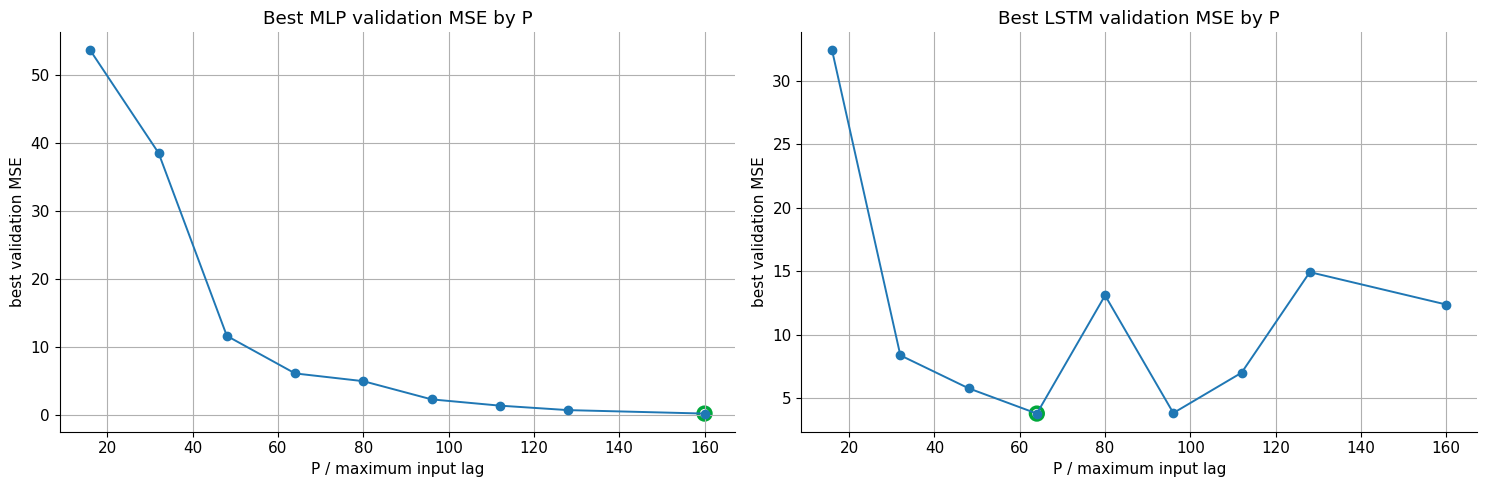

In [13]:

best_by_lag_df = (
    search_results_df
    .sort_values("best_val_mse")
    .groupby(["model_type", "P"], as_index=False)
    .first()
    .sort_values(["model_type", "P"])
)

display(selected_configs_df)
display(best_by_lag_df[["model_type", "P", "hidden", "layer_count", "learning_rate", "best_val_mse", "best_epoch", "seconds"]])

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
for ax, model_type in zip(axes, SEARCH_MODEL_TYPES):
    group = best_by_lag_df.loc[best_by_lag_df["model_type"] == model_type]
    ax.plot(group["P"], group["best_val_mse"], marker="o", linewidth=1.4)
    selected_row = selected_configs[model_type]
    ax.scatter([selected_row["P"]], [selected_row["best_val_mse"]], s=85, facecolors="none", edgecolors="#00a83b", linewidths=2.5)
    ax.set_title(f"Best {model_type} validation MSE by P")
    ax.set_xlabel("P / maximum input lag")
    ax.set_ylabel("best validation MSE")
plt.tight_layout()
plt.show()


### Comments

- P directly controls how much input history is available to the model. Because the true impulse response decays slowly, too small a P truncates meaningful system memory and forces the model to ignore part of the filter response.
- For the MLP, validation MSE improves strongly as P increases, reaching its best value 0.154234 at P=160. This is consistent with the analysis, the process has long memory, so a longer lag window gives the model the information it needs.
- For the LSTM, the best value occurs at P=64 with validation MSE 3.786903, and P=96 is close at 3.829435. The curve shows optimization difficulty and model sensitivity, not an absence of long memory in the data.
- Larger P increases information, but it also increases the problem dimension and sequence length. The MLP handles that extra memory well, while the LSTM does not consistently convert it into better performance.
- The appropriate P should therefore be chosen from both the impulse response decay and validation performance. In this experiment, P=160 is justified for the MLP, while the LSTM's best empirical compromise is P=64.


## Final selected MLP and LSTM training

,model_type,P,hidden,layer_count,learning_rate,search_best_val_mse
0,MLP,160.0,512.0,0.0,0.050,0.154234
1,LSTM,64.0,32.0,3.0,0.005,3.786903


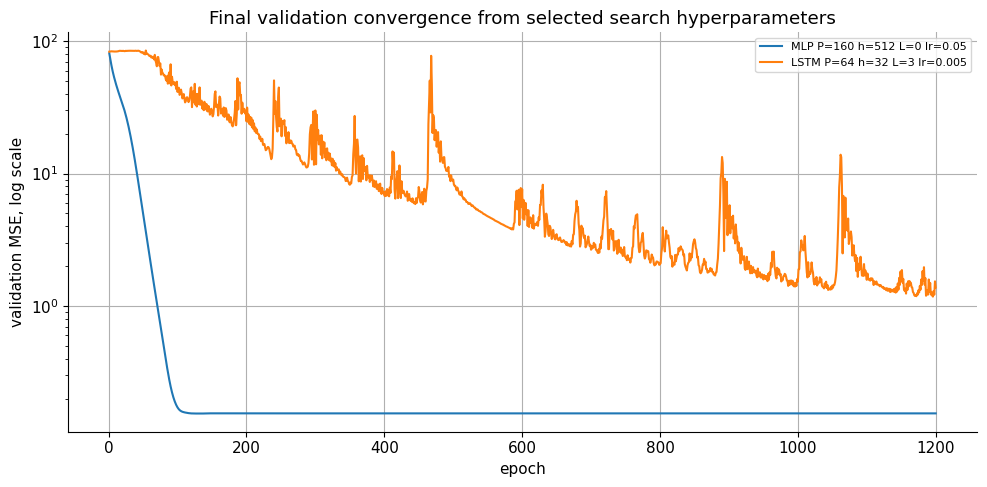

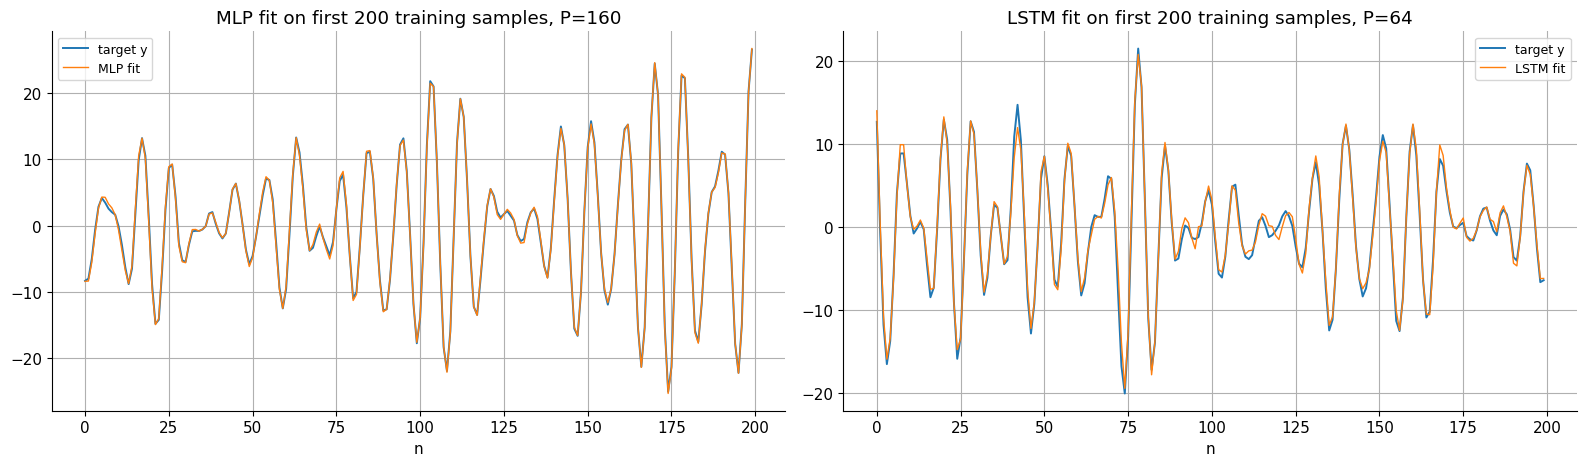

In [14]:

final_models = {}
final_histories = {}
selected_model_configs = {}
training_batches = {}

for model_type in SEARCH_MODEL_TYPES:
    cfg = selected_configs[model_type]
    P_MODEL = int(cfg["P"])
    x_train_model = search_training_data[P_MODEL]["x"]
    X_model = search_training_data[P_MODEL]["X"]
    y_model = search_training_data[P_MODEL]["y"]
    np.save(PROJECT_DIR / f"x_{model_type.lower()}_selected.npy", x_train_model.astype(np.float32))
    np.save(PROJECT_DIR / f"y_{model_type.lower()}_selected.npy", y_model.astype(np.float32))

    selected_model_configs[model_type] = {
        "P": P_MODEL,
        "hidden": int(cfg["hidden"]),
        "layer_count": int(cfg["layer_count"]),
        "learning_rate": float(cfg["learning_rate"]),
        "search_best_val_mse": float(cfg["best_val_mse"]),
    }
    training_batches[model_type] = {"X": X_model, "y": y_model, "x": x_train_model}
    seed_final = NEURAL_PROJECT_SEED + P_MODEL + int(cfg["hidden"])
    torch.manual_seed(seed_final)
    final_model = search_model_builders[model_type](P_MODEL, selected_model_configs[model_type])
    final_model, final_history = train_torch_model(
        final_model,
        X_model,
        y_model,
        epochs=DL_EPOCHS_FINAL,
        lr=float(cfg["learning_rate"]),
        batch_size=DL_BATCH_SIZE,
        val_fraction=SEARCH_TEST_FRACTION,
        seed=seed_final,
    )
    final_models[model_type] = final_model
    final_histories[model_type] = final_history

P_SELECTED_MLP = selected_model_configs["MLP"]["P"]
P_SELECTED_LSTM = selected_model_configs["LSTM"]["P"]
np.save(PROJECT_DIR / "x.npy", training_batches["MLP"]["x"].astype(np.float32))
np.save(PROJECT_DIR / "y.npy", training_batches["MLP"]["y"].astype(np.float32))

torch.save({
    "model": final_models["MLP"].state_dict(),
    "L": P_SELECTED_MLP,
    "hidden": selected_model_configs["MLP"]["hidden"],
    "num_hidden_layers": selected_model_configs["MLP"]["layer_count"],
    "learning_rate": selected_model_configs["MLP"]["learning_rate"],
}, PROJECT_DIR / "Final_simpleMLP.pt")
torch.save({
    "model": final_models["LSTM"].state_dict(),
    "L": P_SELECTED_LSTM,
    "hidden": selected_model_configs["LSTM"]["hidden"],
    "num_layers": selected_model_configs["LSTM"]["layer_count"],
    "learning_rate": selected_model_configs["LSTM"]["learning_rate"],
}, PROJECT_DIR / "Final_simpleLSTM.pt")

final_config_df = pd.DataFrame(selected_model_configs).T.reset_index(names="model_type")
display(final_config_df)

fig, ax = plt.subplots(figsize=(10, 5))
for model_type in SEARCH_MODEL_TYPES:
    history = final_histories[model_type]
    cfg = selected_model_configs[model_type]
    ax.semilogy(history["epoch"], history["val_mse"], label=f"{model_type} P={cfg['P']} h={cfg['hidden']} L={cfg['layer_count']} lr={cfg['learning_rate']}")
ax.set_title("Final validation convergence from selected search hyperparameters")
ax.set_xlabel("epoch")
ax.set_ylabel("validation MSE, log scale")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), sharey=False)
idx_plot = np.arange(200)
for ax, model_type in zip(axes, SEARCH_MODEL_TYPES):
    X_model = training_batches[model_type]["X"]
    y_model = training_batches[model_type]["y"]
    yhat_model = predict_torch_model(final_models[model_type], X_model)
    cfg = selected_model_configs[model_type]
    ax.plot(idx_plot, y_model[idx_plot], label="target y", linewidth=1.4)
    ax.plot(idx_plot, yhat_model[idx_plot], label=f"{model_type} fit", linewidth=1.0)
    ax.set_title(f"{model_type} fit on first 200 training samples, P={cfg['P']}")
    ax.set_xlabel("n")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### Comments

- The final training step fixes the best selected hyperparameters and retrains one representative MLP and one representative LSTM for the later PSD and impulse response experiments.
- The selected MLP remains the stronger model after retraining. Its configuration, P=160 with no hidden layers, effectively learns a finite impulse response approximation to the true linear filter.
- The selected LSTM, P=64 with three recurrent layers, has a visibly weaker fit. Its waveform mismatch indicates that it has not learned the amplitude and phase relationship of the filter as accurately.
- The first 200 sample comparison is useful because it gives a time domain check before looking at spectra. The MLP follows both peaks and sign changes more closely, while the LSTM output is smoother and less faithful.

## (c) Generate new inputs, infer $y_{ML}[n]$, and repeat Part I(e)

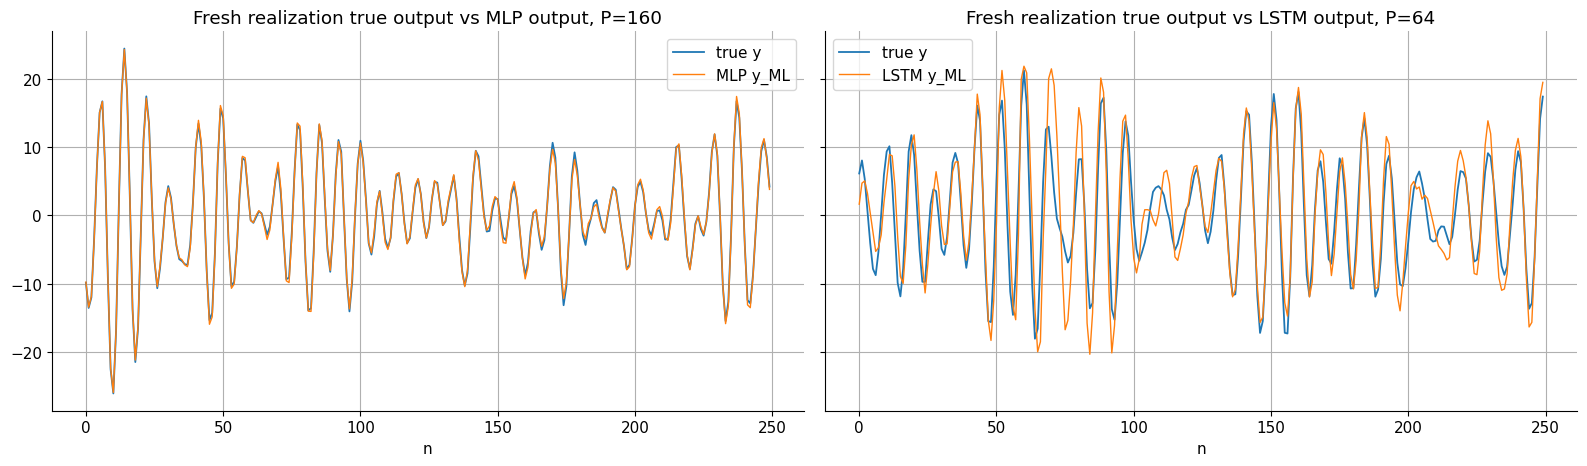

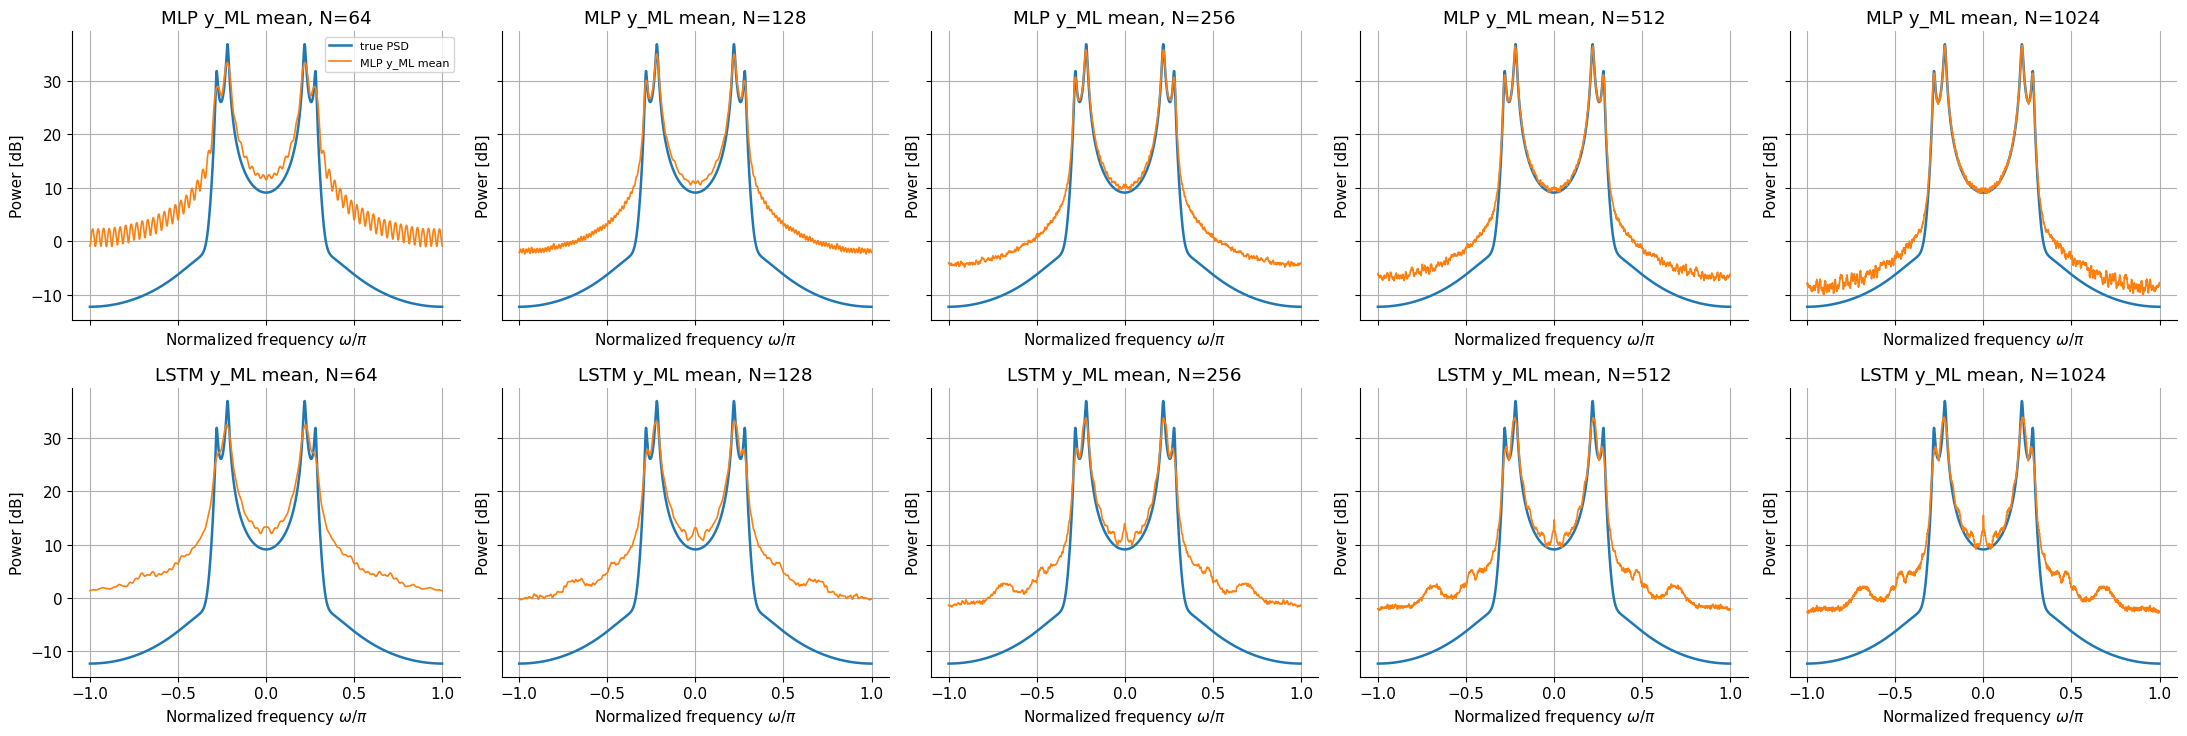

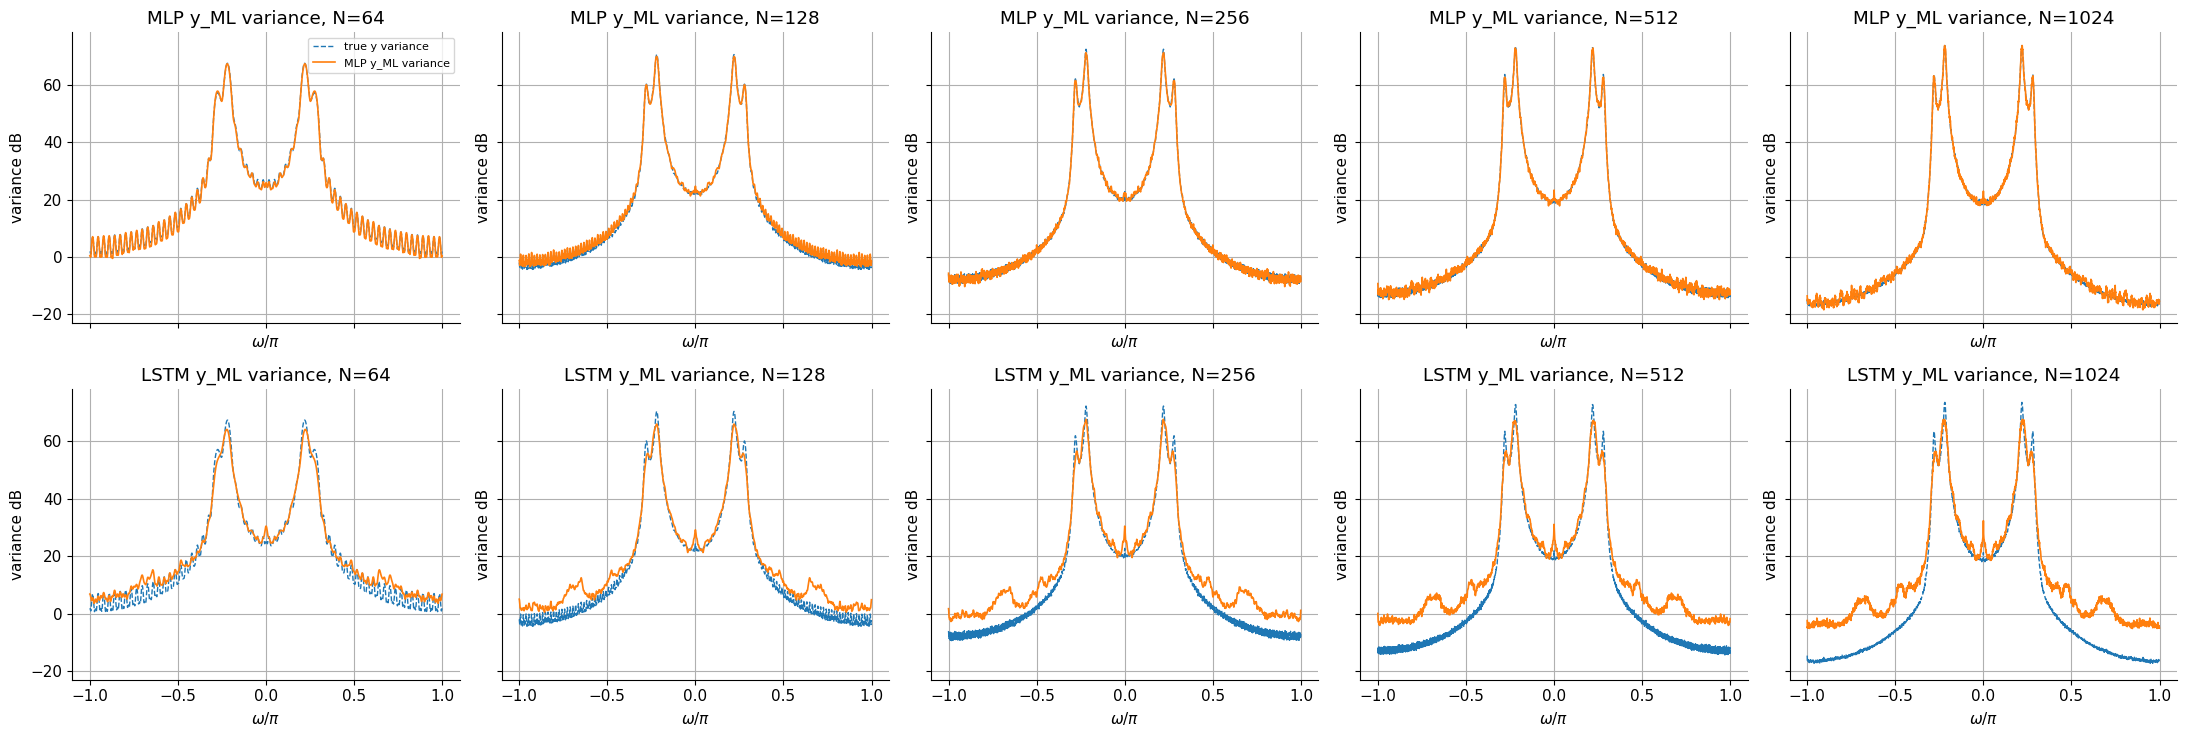

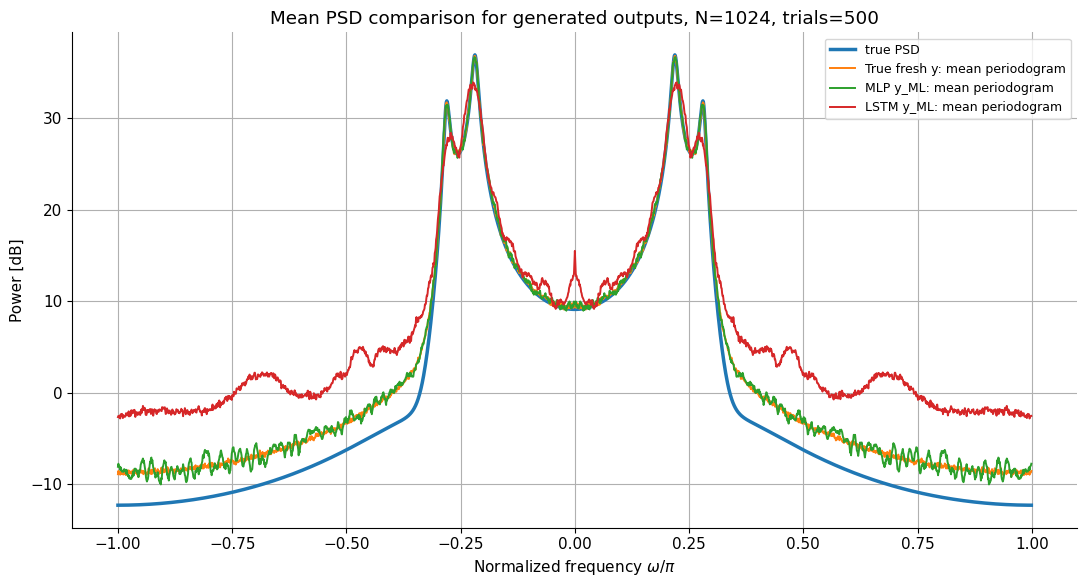

,source,N,trials,mean_abs_error_dB,average_variance
0,True fresh y,64,500,9.521670,156880.961835
1,True fresh y,128,500,7.414286,195812.254840
2,True fresh y,256,500,5.453979,228650.045225
3,True fresh y,512,500,3.732428,270391.288116
4,True fresh y,1024,500,2.384675,288785.148772
5,MLP y_ML,64,500,9.579344,162042.868765
6,MLP y_ML,128,500,7.471617,201457.365851
7,MLP y_ML,256,500,5.531829,233670.996074
8,MLP y_ML,512,500,3.804336,275805.014105
9,MLP y_ML,1024,500,2.459515,293778.700974


In [15]:

ml_psd_results = {}
x_new_batches = {}
y_true_new_batches = {}
y_predict_batches = {}

for model_index, model_type in enumerate(SEARCH_MODEL_TYPES):
    cfg = selected_model_configs[model_type]
    P_MODEL = int(cfg["P"])
    rng_ml = np.random.default_rng(NEURAL_INFERENCE_SEED + model_index + P_MODEL)
    x_new_model = rng_ml.normal(0.0, 1.0, size=(ML_TRIALS, N_MAIN + P_MODEL)).astype(np.float32)
    y_true_full = signal.lfilter(b, a, x_new_model, axis=1)
    y_true_model = y_true_full[:, P_MODEL : P_MODEL + N_MAIN].astype(np.float32)
    y_predict_model = infer_y_from_x_batch(final_models[model_type], x_new_model, P_MODEL)
    x_new_batches[model_type] = x_new_model
    y_true_new_batches[model_type] = y_true_model
    y_predict_batches[model_type] = y_predict_model
    np.save(PROJECT_DIR / f"x_new_{model_type.lower()}.npy", x_new_model.astype(np.float32))
    np.save(OUTPUT_DIR / f"y_true_new_{model_type.lower()}_batch.npy", y_true_model.astype(np.float32))
    np.save(PROJECT_DIR / f"y_predict_{model_type}.npy", y_predict_model.astype(np.float32))

x_new_batch = x_new_batches["MLP"]
y_true_new_batch = y_true_new_batches["MLP"]
y_predict_MLP = y_predict_batches["MLP"]
y_predict_LSTM = y_predict_batches["LSTM"]

ml_psd_results["True fresh y"] = periodogram_stats(y_true_new_batch, N_VALUES, n_fft=N_FFT)
ml_psd_results["MLP y_ML"] = periodogram_stats(y_predict_MLP, N_VALUES, n_fft=N_FFT)
ml_psd_results["LSTM y_ML"] = periodogram_stats(y_predict_LSTM, N_VALUES, n_fft=N_FFT)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), sharey=True)
idx = np.arange(250)
axes[0].plot(idx, y_true_new_batches["MLP"][0, idx], label="true y", linewidth=1.3)
axes[0].plot(idx, y_predict_MLP[0, idx], label="MLP y_ML", linewidth=1.0)
axes[0].set_title(f"Fresh realization true output vs MLP output, P={P_SELECTED_MLP}")
axes[0].set_xlabel("n")
axes[0].legend()
axes[1].plot(idx, y_true_new_batches["LSTM"][0, idx], label="true y", linewidth=1.3)
axes[1].plot(idx, y_predict_LSTM[0, idx], label="LSTM y_ML", linewidth=1.0)
axes[1].set_title(f"Fresh realization true output vs LSTM output, P={P_SELECTED_LSTM}")
axes[1].set_xlabel("n")
axes[1].legend()
plt.tight_layout()
plt.show()

learned_sources = ["MLP y_ML", "LSTM y_ML"]

fig, axes = plt.subplots(len(learned_sources), len(N_VALUES), figsize=(22, 7.5), sharex=True, sharey=True, squeeze=False)
for row, source_name in enumerate(learned_sources):
    for col, N in enumerate(N_VALUES):
        ax = axes[row, col]
        plot_psd_curve(w_grid, S_true_grid, "true PSD", ax=ax, use_db=True, linewidth=1.8)
        plot_psd_curve(w_grid, ml_psd_results[source_name][N]["mean"], f"{source_name} mean", ax=ax, use_db=True, linewidth=1.2)
        ax.set_title(f"{source_name} mean, N={N}")
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(learned_sources), len(N_VALUES), figsize=(22, 7.5), sharex=True, sharey=True, squeeze=False)
for row, source_name in enumerate(learned_sources):
    for col, N in enumerate(N_VALUES):
        ax = axes[row, col]
        ax.plot(w_grid / np.pi, db(period_stats[N]["var"]), linestyle="--", linewidth=1.0, label="true y variance")
        ax.plot(w_grid / np.pi, db(ml_psd_results[source_name][N]["var"]), linewidth=1.2, label=f"{source_name} variance")
        ax.set_title(f"{source_name} variance, N={N}")
        ax.set_xlabel(r"$\omega/\pi$")
        ax.set_ylabel("variance dB")
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

N_COMPARE = 1024
fig, ax = plt.subplots(figsize=(11, 6))
plot_psd_curve(w_grid, S_true_grid, "true PSD", ax=ax, use_db=True, linewidth=2.5)
for name, stats in ml_psd_results.items():
    plot_psd_curve(w_grid, stats[N_COMPARE]["mean"], f"{name}: mean periodogram", ax=ax, use_db=True, linewidth=1.4)
ax.set_title(f"Mean PSD comparison for generated outputs, N={N_COMPARE}, trials={ML_TRIALS}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

ml_summary_rows = []
for name, stats in ml_psd_results.items():
    for N in N_VALUES:
        mean_I = stats[N]["mean"]
        var_I = stats[N]["var"]
        ml_summary_rows.append({
            "source": name,
            "N": N,
            "trials": ML_TRIALS,
            "mean_abs_error_dB": float(np.mean(np.abs(db(mean_I) - db(S_true_grid)))),
            "average_variance": float(np.mean(var_I)),
        })
display(pd.DataFrame(ml_summary_rows))


### Comments

- Repeating the periodogram statistics on learned outputs is a good way to check training loss alone, because it asks whether the generated sequences preserve the second order behavior of the original random process.
- The MLP learned output is very close to the true fresh output. At N=1024, the true fresh y mean PSD error is 2.384675 dB, while MLP y_ML is 2.459515 dB, only slightly worse.
- The MLP variance values are also close to the true y variance values. This indicates that the MLP is not merely producing the correct average spectrum; it is also preserving the randomness level of the periodogram across realizations.
- The LSTM output is worse, with N=1024 mean error 6.922780 dB. Its lower average variance indicates an overly smoothed or underpowered learned process, which suppresses some of the natural spectral variability.
- The conclusion is that the MLP learned a generator whose PSD statistics match the real process well, while the LSTM learned only a rougher approximation that is missing spectral structure.

## (d) Estimate impulse response using sample cross correlation

For a unit variance white input,

$$
\mathbb{E}\{y[n]x[n-k]\}
= \mathbb{E}\left\{\sum_m h[m]x[n-m]x[n-k]\right\}
= h[k].
$$

Therefore, for generated or learned outputs,

$$
\hat h[k] = \frac{1}{M_k}\sum_{n\in \mathcal{I}_k} y[n]x[n-k],
$$

where $\mathcal{I}_k$ contains the valid indices available in the stored input array. Averaging across many realizations makes this estimate cleaner.


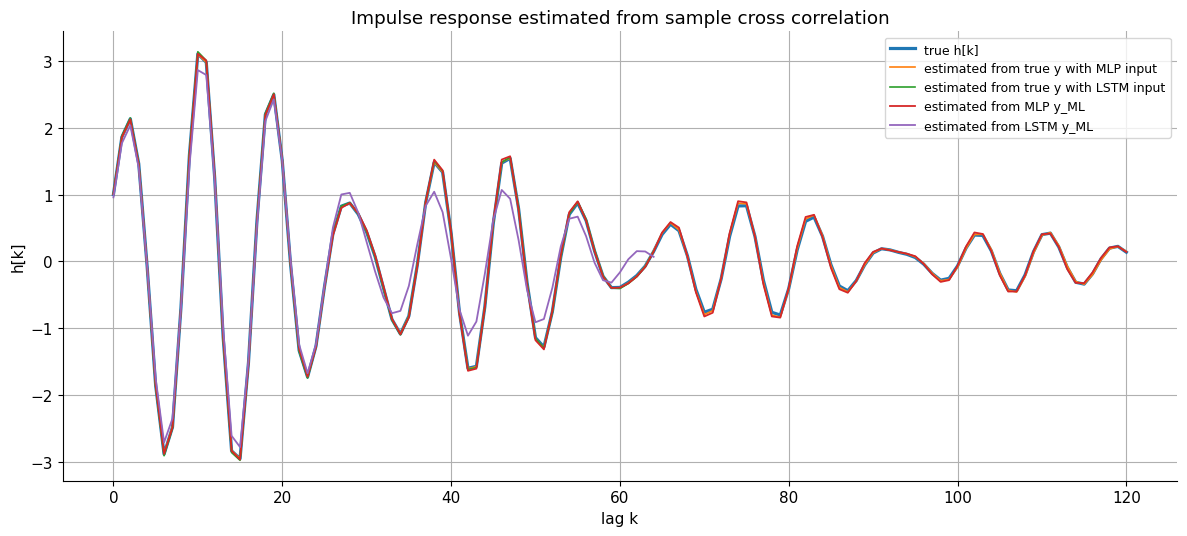

,source,P,RMSE_vs_true_h,max_lag_used,trials
0,true y with MLP input,160,0.014224,120,500
1,true y with LSTM input,64,0.014254,64,500
2,MLP y_ML,160,0.026199,120,500
3,LSTM y_ML,64,0.254897,64,500


In [16]:

def estimate_impulse_from_xy(x_store_batch: np.ndarray, y_batch: np.ndarray, P: int, max_lag: int) -> np.ndarray:
    """Estimate impulse response by sample cross correlation."""
    x_store_batch = np.atleast_2d(np.asarray(x_store_batch, dtype=float))
    y_batch = np.atleast_2d(np.asarray(y_batch, dtype=float))
    N = y_batch.shape[1]
    h_hat = np.zeros(max_lag + 1)
    for k in range(max_lag + 1):
        n_start = max(0, k - P)
        n = np.arange(n_start, N)
        x_idx = P + n - k
        vals = y_batch[:, n] * x_store_batch[:, x_idx]
        h_hat[k] = vals.mean()
    return h_hat


MAX_H_LAG_MLP = min(120, P_SELECTED_MLP)
MAX_H_LAG_LSTM = min(120, P_SELECTED_LSTM)
MAX_H_LAG_TRUE = max(MAX_H_LAG_MLP, MAX_H_LAG_LSTM)

h_hat_true_mlp = estimate_impulse_from_xy(x_new_batches["MLP"], y_true_new_batches["MLP"], P_SELECTED_MLP, MAX_H_LAG_MLP)
h_hat_true_lstm = estimate_impulse_from_xy(x_new_batches["LSTM"], y_true_new_batches["LSTM"], P_SELECTED_LSTM, MAX_H_LAG_LSTM)
h_hat_mlp = estimate_impulse_from_xy(x_new_batches["MLP"], y_predict_MLP, P_SELECTED_MLP, MAX_H_LAG_MLP)
h_hat_lstm = estimate_impulse_from_xy(x_new_batches["LSTM"], y_predict_LSTM, P_SELECTED_LSTM, MAX_H_LAG_LSTM)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(np.arange(MAX_H_LAG_TRUE + 1), h_true_long[: MAX_H_LAG_TRUE + 1], label="true h[k]", linewidth=2.3)
ax.plot(np.arange(MAX_H_LAG_MLP + 1), h_hat_true_mlp, label="estimated from true y with MLP input", linewidth=1.2)
ax.plot(np.arange(MAX_H_LAG_LSTM + 1), h_hat_true_lstm, label="estimated from true y with LSTM input", linewidth=1.2)
ax.plot(np.arange(MAX_H_LAG_MLP + 1), h_hat_mlp, label="estimated from MLP y_ML", linewidth=1.3)
ax.plot(np.arange(MAX_H_LAG_LSTM + 1), h_hat_lstm, label="estimated from LSTM y_ML", linewidth=1.3)
ax.set_title("Impulse response estimated from sample cross correlation")
ax.set_xlabel("lag k")
ax.set_ylabel("h[k]")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

impulse_summary = pd.DataFrame({
    "source": ["true y with MLP input", "true y with LSTM input", "MLP y_ML", "LSTM y_ML"],
    "P": [P_SELECTED_MLP, P_SELECTED_LSTM, P_SELECTED_MLP, P_SELECTED_LSTM],
    "RMSE_vs_true_h": [
        float(np.sqrt(np.mean((h_hat_true_mlp - h_true_long[: MAX_H_LAG_MLP + 1]) ** 2))),
        float(np.sqrt(np.mean((h_hat_true_lstm - h_true_long[: MAX_H_LAG_LSTM + 1]) ** 2))),
        float(np.sqrt(np.mean((h_hat_mlp - h_true_long[: MAX_H_LAG_MLP + 1]) ** 2))),
        float(np.sqrt(np.mean((h_hat_lstm - h_true_long[: MAX_H_LAG_LSTM + 1]) ** 2))),
    ],
    "max_lag_used": [MAX_H_LAG_MLP, MAX_H_LAG_LSTM, MAX_H_LAG_MLP, MAX_H_LAG_LSTM],
    "trials": ML_TRIALS,
})
display(impulse_summary)


### Comments

- The estimates from true y give RMSE values around 0.014, which establishes the finite sample baseline. With 500 realizations, the method is accurate enough to recover the true impulse response shape.
- The MLP learned output gives RMSE 0.026199. This is just above the true y baseline, so the MLP has learned an effective filter very close to the original system over the lag window.
- The LSTM learned output gives RMSE 0.254897, much worse than both the baseline and the MLP. This confirms that the LSTM's poorer PSD behavior comes from an incorrect learned input output filter, not only from noise.
- A model that truly learns the generator should match both the PSD and the impulse response. The MLP passes that test much more convincingly than the LSTM.